In [2]:
import pandas as pd

### OVERVIEW DEL DATASET

In [3]:
df = pd.read_excel("storico_investimenti.xlsx")
df.head()

,Azienda,Codice Fiscale,Data,Tipo Evento,Round Type,Importo (EUR),Importo (Mln €),Investitori,Fonte,Verifica
0,Subbyx,12913000969,2023,funding_round,primary,15000000.0,15.0,"Azimut Venture Capital Digitech Europe, Azimut...",https://ntplusdiritto.ilsole24ore.com/art/subb...,verificato
1,Subbyx,12913000969,2026-03-25,funding_round,primary,30000000.0,30.0,"Systemiq Capital, Azimut, Flashpoint",https://tech.eu/2026/03/25/with-eur30m-series-...,verificato
2,Subbyx,12913000969,2025-02-02,funding_round,primary,20000000.0,20.0,"Azimut Venture Capital Digitech Europe, Azimut...",https://www.startupbusiness.it/en/azimut-backe...,sospetto
3,Subbyx,12913000969,2025-03-02,funding_round,primary,15600000.0,15.6,Azimut Digitech Fund,https://www.linkedin.com/company/subbyx,verificato
4,Subbyx,12913000969,2024-01-01,funding_round,primary,30000000.0,30.0,"Systemiq Capital, Azimut, Flashpoint",https://www.linkedin.com/posts/tviguier_subbyx...,sospetto


In [4]:
df.columns

Index(['Azienda', 'Codice Fiscale', 'Data', 'Tipo Evento', 'Round Type',
       'Importo (EUR)', 'Importo (Mln €)', 'Investitori', 'Fonte', 'Verifica'],
      dtype='str')

In [5]:
# ── 1. OVERVIEW GENERALE ─────────────────────────────────────
print(f"Shape: {df.shape}")
print(f"Aziende uniche: {df['Azienda'].nunique()}")
print()


Shape: (330, 10)
Aziende uniche: 229



In [6]:
# ── 2. DATE ──────────────────────────────────────────────────
df['Data'] = pd.to_datetime(df['Data'], errors='coerce')
df['anno'] = df['Data'].dt.year.astype('Int64')
print("=== DATE MANCANTI ===")
print(f"Date mancanti: {df['Data'].isna().sum()} su {len(df)}")
print()
print("=== DISTRIBUZIONE ANNI ===")
print(df['anno'].value_counts().sort_index())
print()

=== DATE MANCANTI ===
Date mancanti: 291 su 330

=== DISTRIBUZIONE ANNI ===
anno
2002     1
2019     1
2020     2
2021     2
2022     8
2023     8
2024    12
2025     4
2026     1
Name: count, dtype: Int64



In [7]:
# ── 3. TIPO EVENTO ───────────────────────────────────────────
print("=== TIPO EVENTO ===")
print(df['Tipo Evento'].value_counts())
print()

=== TIPO EVENTO ===
Tipo Evento
funding_round       229
share_sale           68
other                27
capital_increase      6
Name: count, dtype: int64



In [8]:
# ── 4. ROUND TYPE — pulizia ──────────────────────────────────
print("=== ROUND TYPE (raw) ===")
print(df['Round Type'].value_counts())
print()

def clean_round_type(val):
    if pd.isna(val):
        return 'undetermined'
    val = val.strip().lower()
    if 'startup' in val or val in ['tartup', 'rtup', 'artup', 'tup']:
        return 'startup'
    if 'enterprise' in val or 'enterp' in val or val in ['ed', 'enterp', 'enterpis']:
        return 'enterprise'
    if 'later' in val:
        return 'later stage'
    return val

df['round_type_clean'] = df['Round Type'].apply(clean_round_type)
print("=== ROUND TYPE (pulito) ===")
print(df['round_type_clean'].value_counts())
print()

=== ROUND TYPE (raw) ===
Round Type
primary            214
secondary           56
undetermined        28
mixed                9
seed                 6
startup              2
ed                   2
tartup               2
rtup                 2
artup                2
later       pr       1
tup                  1
tup enterpr          1
d                    1
enterp               1
enterpris            1
later       pri      1
Name: count, dtype: int64

=== ROUND TYPE (pulito) ===
round_type_clean
primary         214
secondary        56
undetermined     28
mixed             9
startup           9
seed              6
enterprise        5
later stage       2
d                 1
Name: count, dtype: int64



In [9]:
# ── 5. VERIFICA ──────────────────────────────────────────────
print("=== VERIFICA ===")
print(df['Verifica'].value_counts())
df['is_verified'] = df['Verifica'].str.startswith('verificato')
print(f"\nVerificati totali: {df['is_verified'].sum()}")
print(f"Sospetti: {(~df['is_verified']).sum()}")
print()

=== VERIFICA ===
Verifica
verificato            280
sospetto               26
verificato_vem2024     10
verificato_vem2022      6
verificato_vem2023      4
verificato_vem2020      2
verificato_vem2021      2
Name: count, dtype: int64

Verificati totali: 304
Sospetti: 26



In [10]:
# ── 6. IMPORTI ───────────────────────────────────────────────
print("=== IMPORTI (Mln €) ===")
print(f"Mancanti: {df['Importo (Mln €)'].isna().sum()} su {len(df)}")
print(df['Importo (Mln €)'].describe())
print()

print("=== TOP 10 IMPORTI ===")
print(df[['Azienda', 'Data', 'Importo (Mln €)', 'Verifica']]
      .sort_values('Importo (Mln €)', ascending=False)
      .head(10).to_string())
print()


=== IMPORTI (Mln €) ===
Mancanti: 84 su 330
count     246.000000
mean       43.050569
std       309.234206
min         0.000000
25%         1.097500
50%         4.000000
75%        12.007500
max      4750.000000
Name: Importo (Mln €), dtype: float64

=== TOP 10 IMPORTI ===
               Azienda       Data  Importo (Mln €)    Verifica
82             ECO LAB        NaT           4750.0  verificato
42               Itaca        NaT            600.0  verificato
218           NET Zero        NaT            554.0  verificato
78       Avio Solution        NaT            400.0  verificato
213   EXA Applications        NaT            250.0  verificato
53                 RLH        NaT            250.0  verificato
185           Axxelera        NaT            250.0  verificato
150    Hybris Advisory 2002-01-01            225.0  verificato
93         MIA Fintech        NaT            202.0  verificato
190  G D G Engineering        NaT            175.0  verificato



In [11]:
# ── 7. INVESTITORI ───────────────────────────────────────────
print("=== INVESTITORI — valori anomali ===")
anomalie = df[df['Investitori'].str.contains('Country', na=False)]
print(f"Righe con 'Country' come investitore: {len(anomalie)}")
print(anomalie[['Azienda', 'Data', 'Investitori']].head(5).to_string())
print()

investors_series = (
    df['Investitori']
    .dropna()
    .str.split(',')
    .explode()
    .str.strip()
)
investors_clean = investors_series[investors_series != 'Country']
print("=== TOP 20 INVESTITORI (puliti) ===")
print(investors_clean.value_counts().head(20))
print()


=== INVESTITORI — valori anomali ===
Righe con 'Country' come investitore: 22
          Azienda Data                                                                                                                                          Investitori
14      Viceversa  NaT         CDP Venture Capital, Azimut Digitech Fund, Kairos Partners SGR, Italian Angels for Growth, Fabrick, Raffaele Terrone, Paolo Galvani, Country
101  Data Masters  NaT                                                                                                                                        Country, Seed
158         Macai  NaT            Lumen Ventures, Plug and Play Ventures, Cats.VC, other undisclosed institutional and private investors, Country, &Play, Cats.vc      Seed
180        Ebamed  NaT  Panakès Partners, EIC Fund, Swiss EFI Lake Geneva Ventures, LIFTT Venture Capital Italia, OCCIDENT, Mayo Clinic, Country, Lake Geneva         Star
250  Data Masters  NaT            Primo Ventures, Zanichelli V

### CHI FINANZIA

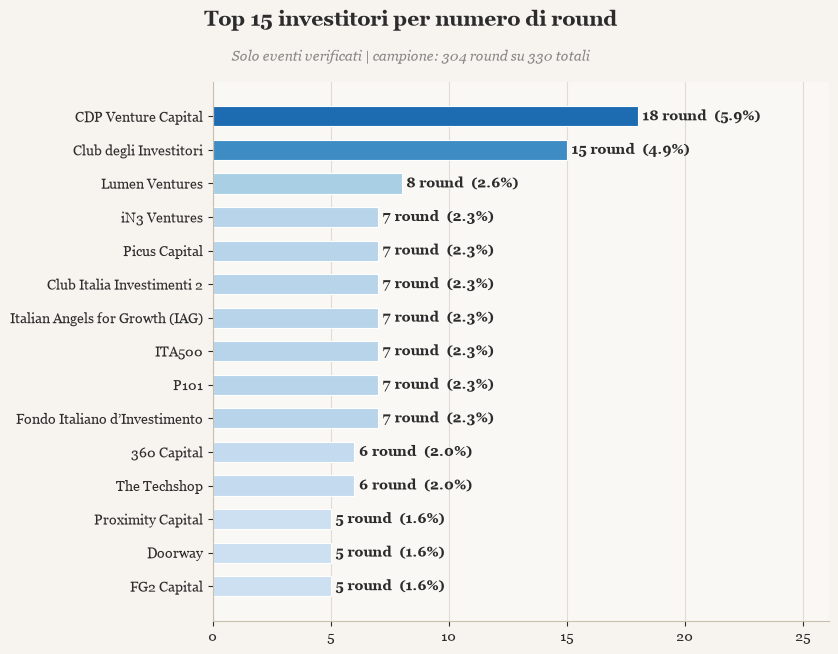

In [12]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm
import pandas as pd

try:
    fm.findfont('Georgia', rebuild_if_missing=False)
    mpl.rcParams['font.family'] = 'Georgia'
except:
    mpl.rcParams['font.family'] = 'serif'

df = pd.read_excel("/Users/claudiatimis/Desktop/ANALISI STARTUP/storico_investimenti.xlsx")

# ── 1. PULIZIA ───────────────────────────────────────────────
df['is_verified'] = df['Verifica'].str.startswith('verificato')
df_verified = df[df['is_verified']].copy()

investors = (
    df_verified['Investitori']
    .dropna()
    .str.split(',')
    .explode()
    .str.strip()
)

investors = investors[investors != 'Country']

normalize_map = {
    'CDP Venture Capital':             'CDP Venture Capital',
    'Cdp Venture Capital':             'CDP Venture Capital',
    'CDP Venture Capital SGR':         'CDP Venture Capital',
    'Cdp Venture Capital Sgr':         'CDP Venture Capital',
    'Club degli Investitori':          'Club degli Investitori',
    'Club degli investitori':          'Club degli Investitori',
    'iN3 Ventures':                    'iN3 Ventures',
    'In3 Ventures':                    'iN3 Ventures',
    'ITA500':                          'ITA500',
    'Ita500':                          'ITA500',
    'Italian angels for growth (IAG)': 'Italian Angels for Growth (IAG)',
    'Italian Angels For Growth (Iag)': 'Italian Angels for Growth (IAG)',
    'P101':                            'P101',
    "Fondo Italiano d'Investimento":   "Fondo Italiano d'Investimento",
    "Fondo Italiano D'Investimento":   "Fondo Italiano d'Investimento",
    '360 Capital':                     '360 Capital',
    'Picus Capital':                   'Picus Capital',
    'Lumen Ventures':                  'Lumen Ventures',
    'The Techshop':                    'The Techshop',
    'Doorway':                         'Doorway',
    'FG2 Capital':                     'FG2 Capital',
    'Fg2 Capital':                     'FG2 Capital',
    'Proximity Capital':               'Proximity Capital',
    'Club Italia Investimenti 2':      'Club Italia Investimenti 2',
    'Club Italia investimenti 2':      'Club Italia Investimenti 2',
    'Azimut':                          'Azimut',
}

investors = investors.map(lambda x: normalize_map.get(x, x))

top15 = (
    investors
    .value_counts()
    .head(15)
    .sort_values(ascending=True)
    .reset_index()
)
top15.columns = ['investitore', 'n_round']
top15['pct'] = (top15['n_round'] / len(df_verified) * 100).round(1)

# ── 2. COLORI ────────────────────────────────────────────────
cmap = mpl.colormaps['Blues']
norm = mpl.colors.Normalize(vmin=0, vmax=top15['n_round'].max() * 1.3)
colori = [cmap(norm(n)) for n in top15['n_round']]

# ── 3. FIGURA ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor('#f7f4ef')
ax.set_facecolor('#faf8f4')
fig.subplots_adjust(left=0.32, right=0.88, top=0.85, bottom=0.08)

bars = ax.barh(
    top15['investitore'],
    top15['n_round'],
    color=colori,
    edgecolor='white',
    linewidth=0.8,
    height=0.6,
)

# Etichette a destra
for bar, (_, row) in zip(bars, top15.iterrows()):
    ax.text(
        bar.get_width() + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f"{int(row['n_round'])} round  ({row['pct']}%)",
        va='center', ha='left',
        fontsize=10, color='#2c2c2c', fontweight='bold'
    )

# ── 4. STILE ─────────────────────────────────────────────────
fig.text(
    0.5, 0.93,
    'Top 15 investitori per numero di round',
    ha='center', fontsize=15, color='#2c2c2c', fontweight='bold'
)
fig.text(
    0.5, 0.88,
    f'Solo eventi verificati | campione: {len(df_verified)} round su {len(df)} totali',
    ha='center', fontsize=10, color='#888888', style='italic'
)

ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='y', labelsize=10, colors='#2c2c2c')
ax.tick_params(axis='x', labelsize=10, colors='#2c2c2c')
ax.set_xlim(0, top15['n_round'].max() * 1.45)
ax.xaxis.grid(True, color='#e0dbd4', linewidth=0.8)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#c8bfb0')
ax.spines['bottom'].set_color('#c8bfb0')

plt.show()

### Versione 2 - usiamo dataset storico_investimenti - se no non c'è coerenza con la heatmap

In [13]:
df = pd.read_excel("/Users/claudiatimis/Desktop/ANALISI STARTUP/storico_investimenti.xlsx")
df['is_verified'] = df['Verifica'].str.startswith('verificato')
df_verified = df[df['is_verified']].copy()

investors_raw = (
    df_verified['Investitori']
    .dropna()
    .str.split(',')
    .explode()
    .str.strip()
)
investors_raw = investors_raw[investors_raw != 'Country']

print(investors_raw.value_counts().to_string())

Investitori
CDP Venture Capital                                          9
Lumen Ventures                                               8
Club degli Investitori                                       8
Fondo Italiano d’Investimento                                7
P101                                                         7
ITA500                                                       7
Italian angels for growth (IAG)                              7
Club degli investitori                                       7
Club Italia investimenti 2                                   7
Picus Capital                                                7
iN3 Ventures                                                 7
The Techshop                                                 6
360 Capital                                                  6
Cdp Venture Capital                                          5
FG2 Capital                                                  5
Doorway                                    

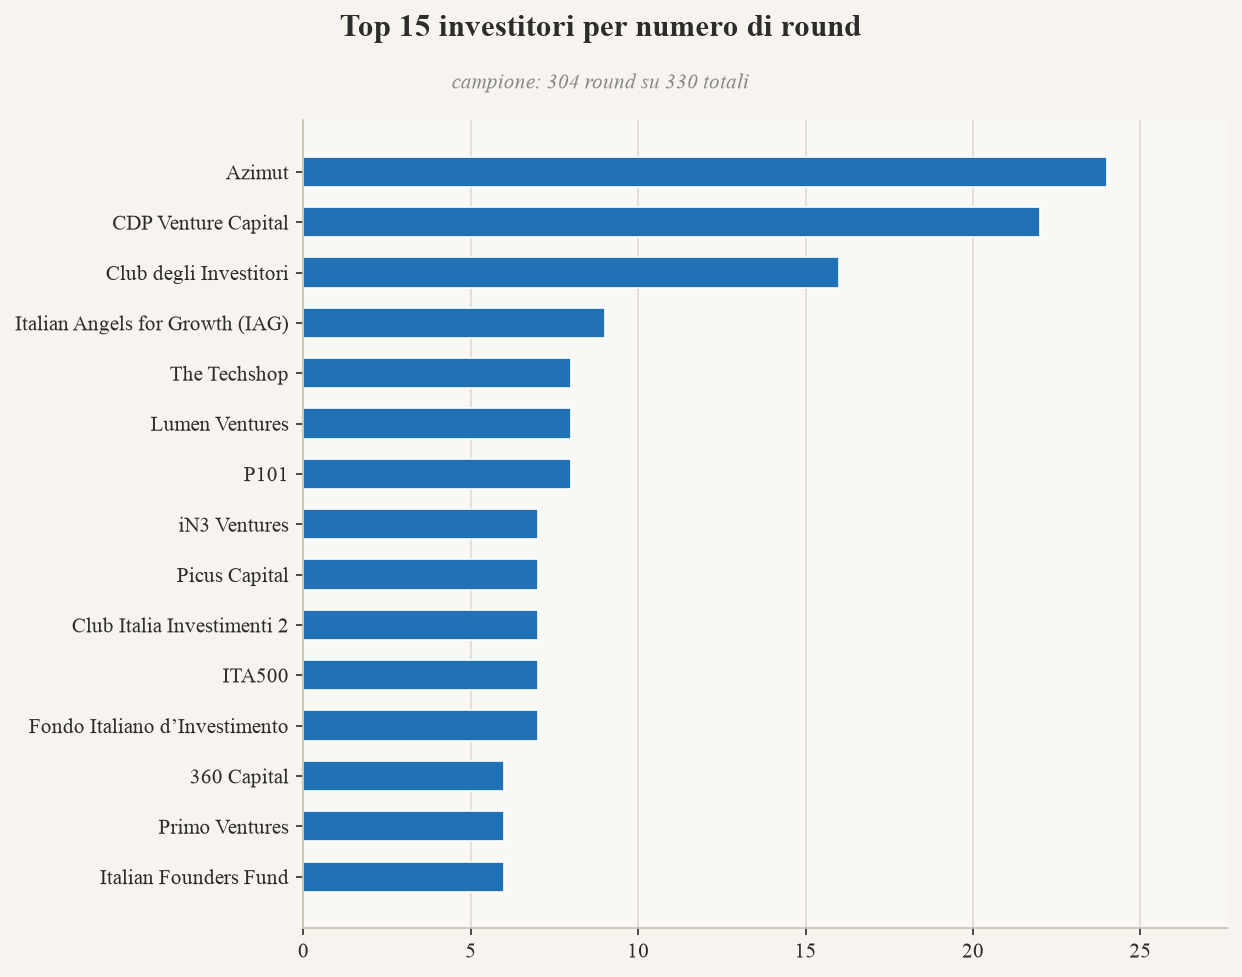

In [14]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd

mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['figure.dpi'] = 150

df = pd.read_excel("/Users/claudiatimis/Desktop/ANALISI STARTUP/storico_investimenti.xlsx")

# ── 1. PULIZIA ───────────────────────────────────────────────
df['is_verified'] = df['Verifica'].str.startswith('verificato')
df_verified = df[df['is_verified']].copy()

investors = (
    df_verified['Investitori']
    .dropna()
    .str.split(',')
    .explode()
    .str.strip()
)
investors = investors[investors != 'Country']

normalize_map = {
    'CDP Venture Capital':                                'CDP Venture Capital',
    'Cdp Venture Capital':                                'CDP Venture Capital',
    'CDP Venture Capital SGR':                            'CDP Venture Capital',
    'CDP Venture Capital Sgr':                            'CDP Venture Capital',
    'CDP VC':                                             'CDP Venture Capital',
    'Artificial Intelligence Fund of CDP Venture Capital':'CDP Venture Capital',
    'Club degli Investitori':                             'Club degli Investitori',
    'Club degli investitori':                             'Club degli Investitori',
    'Club Degli Investitori':                             'Club degli Investitori',
    'Italian angels for growth (IAG)':                   'Italian Angels for Growth (IAG)',
    'Italian Angels for Growth':                          'Italian Angels for Growth (IAG)',
    'Italian Founders Fund (IFF)':                        'Italian Founders Fund',
    'IFF':                                                'Italian Founders Fund',
    'iN3 Ventures':                                       'iN3 Ventures',
    'In3 Ventures':                                       'iN3 Ventures',
    'ITA500':                                             'ITA500',
    'Ita500':                                             'ITA500',
    "Fondo Italiano d'Investimento":                      "Fondo Italiano d'Investimento",
    "Fondo Italiano D'Investimento":                      "Fondo Italiano d'Investimento",
    "Fondo Italiano d'Investimento SGR":                  "Fondo Italiano d'Investimento",
    'Club Italia investimenti 2':                         'Club Italia Investimenti 2',
    'Club Italia Investimenti 2':                         'Club Italia Investimenti 2',
    'Azimut':                                             'Azimut',
    'Azimut Digitech Fund':                               'Azimut',
    'Azimut Libera Impresa':                              'Azimut',
    'Azimut Libera Impresa sgr':                          'Azimut',
    'Azimut Libera Impresa SGR':                          'Azimut',
    'Azimut Venture Capital Digitech Europe':             'Azimut',
    'Azimut Eltif-Venture Capital Alicrowd III':          'Azimut',
    'Azimut Eltif-Venture Capital Alicrowd IV':           'Azimut',
    'Azimut Eltif':                                       'Azimut',
    'Venture Capital Alicrowd II':                        'Azimut',
    'AZIMUT ELTIF – Venture Capital ALIcrowd III and IV': 'Azimut',
    'AZIMUT ELTIF – Venture Capital ALIcrowd II':         'Azimut',
    'Gruppo Azimut':                                      'Azimut',
    'Gellify/Digitech Fund':                              'Azimut',
    'The Techshop':                                       'The Techshop',
    'The Techshop SGR':                                   'The Techshop',
    'echshop SGR':                                        'The Techshop',
    'P101':                                               'P101',
    'P101 SGR':                                           'P101',
    'Plug and Play Tech Center':                          'Plug and Play',
    'Plug and Play Ventures':                             'Plug and Play',
    'Plug & Play Tech Center':                            'Plug and Play',
    'RTP Global':                                         'RTP Global',
    'Rtp Global':                                         'RTP Global',
    'Primo Capital':                                      'Primo Ventures',
    'Primo Ventures':                                     'Primo Ventures',
    'Advent International':                               'Advent International',
    'Advent International L.P.':                          'Advent International',
    'FG2 Capital':                                        'FG2 Capital',
    'Fg2 Capital':                                        'FG2 Capital',
    'LMDV Capital':                                       'LMDV Capital',
    'Lmdv Capital':                                       'LMDV Capital',
    'Mass Mutual Ventures':                               'MassMutual Ventures',
    'MassMutual Ventures Southeast Asia':                 'MassMutual Ventures',
    'MassMutual Ventures':                                'MassMutual Ventures',
    'Itacha Investments':                                 'Ithaca Investment',
    'Ithaca Investment':                                  'Ithaca Investment',
    'Exor Seeds           Seed':                          'Exor Seeds',
    'Exor Seeds':                                         'Exor Seeds',
    '40Jemz Ventures':                                    '40Jemz',
    '40Jemz':                                             '40Jemz',
    'LVenture':                                           'LVenture Group',
    'LVenture Group':                                     'LVenture Group',
    'Vertis':                                             'Vertis SGR',
    'Vertis SGR':                                         'Vertis SGR',
    'PranaVentures':                                      'Prana Ventures',
    'Prana Ventures':                                     'Prana Ventures',
    'LA4G - Luiss Alumni for Growth':                     'La4G',
    'La4G':                                               'La4G',
    'Hummingbird':                                        'Hummingbird Ventures',
    'Hummingbird Ventures':                               'Hummingbird Ventures',
    'Lightspeed':                                         'Lightspeed Venture Partners',
    'Lightspeed Venture Partners':                        'Lightspeed Venture Partners',
    'Pitchdrive':                                         'PitchDrive',
    'PitchDrive':                                         'PitchDrive',
    'a16z':                                               'Andreessen Horowitz',
    'Andreessen Horowitz':                                'Andreessen Horowitz',
    'Wise3':                                              'Wise3 Ventures',
    'Wise3 Ventures':                                     'Wise3 Ventures',
    # Rumori → None
    'Foreign':                                            None,
    'Seed':                                               None,
    'See':                                                None,
    'Star':                                               None,
    'Sta':                                                None,
    'S':                                                  None,
    'Se':                                                 None,
    'Country':                                            None,
    'business angel':                                     None,
    'business angels':                                    None,
    'angel investor':                                     None,
    'family office':                                      None,
    'investitori USA':                                    None,
    'international business angels':                      None,
    'business angel italiani e internazionali':           None,
    'altri fondi di venture capital':                     None,
    'imprenditori internazionali nel settore tech':       None,
    'a group of private investors':                       None,
    'five third-party investors':                         None,
    'other undisclosed institutional and private investors': None,
    '~30 investitori istituzionali':                      None,
    'gruppo di investitori privati':                      None,
    '175 investors':                                      None,
    '1 Other investor':                                   None,
    '8831356':                                            None,
    '5852643':                                            None,
    '8746202':                                            None,
    '3839674':                                            None,
    '2302':                                               None,
    '8228':                                               None,
}

investors = investors.map(lambda x: normalize_map.get(x, x))
investors = investors[investors.notna()]

top15 = (
    investors
    .value_counts()
    .head(15)
    .sort_values(ascending=True)
    .reset_index()
)
top15.columns = ['investitore', 'n_round']

# ── 2. FIGURA ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor('#f7f4ef')
ax.set_facecolor('#faf8f4')
fig.subplots_adjust(left=0.32, right=0.88, top=0.85, bottom=0.08)

ax.barh(
    top15['investitore'],
    top15['n_round'],
    color='#2171b5',
    edgecolor='white',
    linewidth=0.8,
    height=0.6,
)

# ── 3. STILE ─────────────────────────────────────────────────
fig.text(
    0.5, 0.93,
    'Top 15 investitori per numero di round',
    ha='center', fontsize=15, color='#2c2c2c', fontweight='bold'
)
fig.text(
    0.5, 0.88,
    f'campione: {len(df_verified)} round su {len(df)} totali',
    ha='center', fontsize=10, color='#888888', style='italic'
)

ax.tick_params(axis='y', labelsize=10, colors='#2c2c2c')
ax.tick_params(axis='x', labelsize=10, colors='#2c2c2c')
ax.set_xlim(0, top15['n_round'].max() * 1.15)
ax.xaxis.grid(True, color='#e0dbd4', linewidth=0.8)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#c8bfb0')
ax.spines['bottom'].set_color('#c8bfb0')

plt.show()

### DISTRIBUZIONE DEI TIPI DI EVENTO IN PERCENTUALE

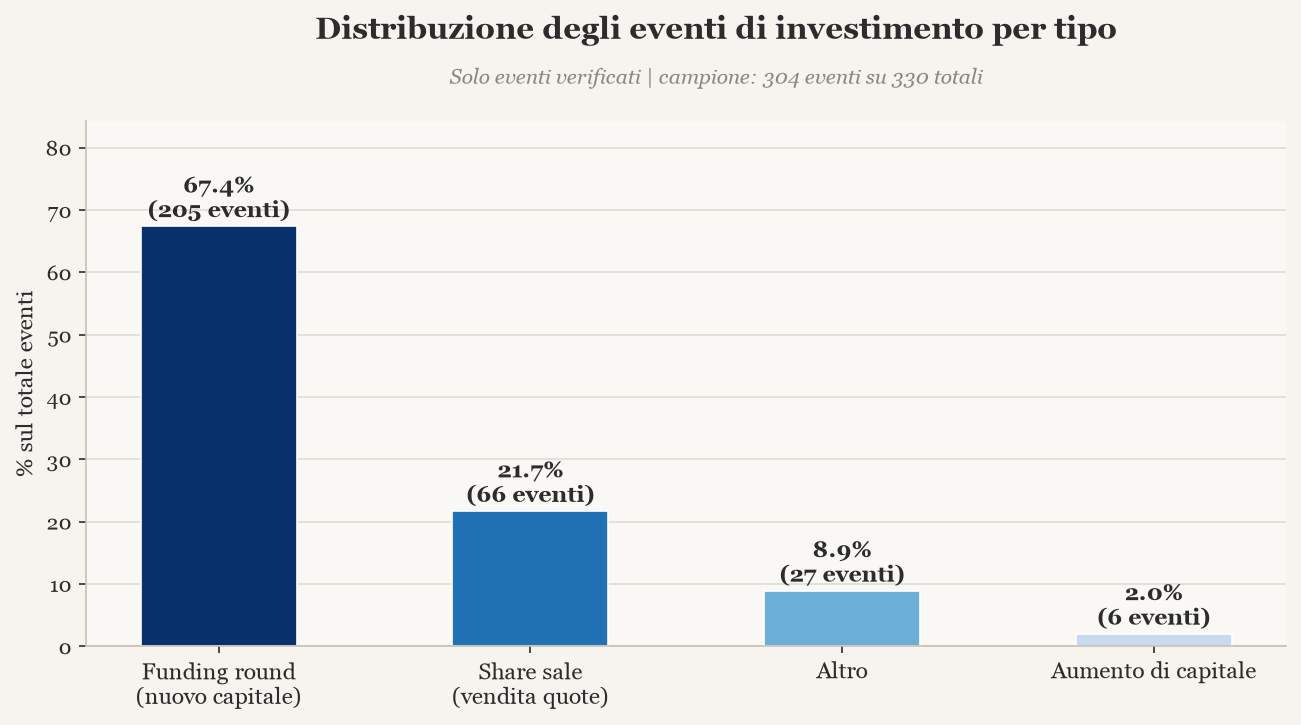

In [15]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm
import pandas as pd

try:
    fm.findfont('Georgia', rebuild_if_missing=False)
    mpl.rcParams['font.family'] = 'Georgia'
except:
    mpl.rcParams['font.family'] = 'serif'

df = pd.read_excel("/Users/claudiatimis/Desktop/ANALISI STARTUP/storico_investimenti.xlsx")

# ── 1. PULIZIA ───────────────────────────────────────────────
df['is_verified'] = df['Verifica'].str.startswith('verificato')
df_verified = df[df['is_verified']].copy()

label_map = {
    'funding_round':    'Funding round\n(nuovo capitale)',
    'share_sale':       'Share sale\n(vendita quote)',
    'other':            'Altro',
    'capital_increase': 'Aumento di capitale',
}
df_verified['tipo_label'] = df_verified['Tipo Evento'].map(label_map).fillna('Altro')

agg = (
    df_verified.groupby('tipo_label')
    .size()
    .reset_index(name='n')
    .sort_values('n', ascending=False)
    .reset_index(drop=True)
)
agg['pct'] = (agg['n'] / agg['n'].sum() * 100).round(1)

# ── 2. COLORI ────────────────────────────────────────────────
colori = ['#08306b', '#2171b5', '#6baed6', '#c6dbef']

# ── 3. FIGURA ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#f7f4ef')
ax.set_facecolor('#faf8f4')
fig.subplots_adjust(left=0.08, right=0.88, top=0.82, bottom=0.12)

bars = ax.bar(
    agg['tipo_label'],
    agg['pct'],
    color=colori[:len(agg)],
    edgecolor='white',
    linewidth=0.8,
    width=0.5,
)

# Etichette sopra ogni barra
for bar, (_, row) in zip(bars, agg.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{row['pct']}%\n({int(row['n'])} eventi)",
        ha='center', va='bottom',
        fontsize=11, color='#2c2c2c', fontweight='bold'
    )

# ── 4. STILE ─────────────────────────────────────────────────
fig.text(
    0.5, 0.93,
    'Distribuzione degli eventi di investimento per tipo',
    ha='center', fontsize=15, color='#2c2c2c', fontweight='bold'
)
fig.text(
    0.5, 0.87,
    f'Solo eventi verificati | campione: {len(df_verified)} eventi su {len(df)} totali',
    ha='center', fontsize=10, color='#888888', style='italic'
)

ax.set_ylabel('% sul totale eventi', fontsize=11, color='#2c2c2c')
ax.set_xlabel('')
ax.tick_params(axis='x', labelsize=11, colors='#2c2c2c')
ax.tick_params(axis='y', labelsize=10, colors='#2c2c2c')
ax.set_ylim(0, agg['pct'].max() * 1.25)
ax.yaxis.grid(True, color='#e0dbd4', linewidth=0.8)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#c8bfb0')
ax.spines['bottom'].set_color('#c8bfb0')

plt.show()

### Versione 2

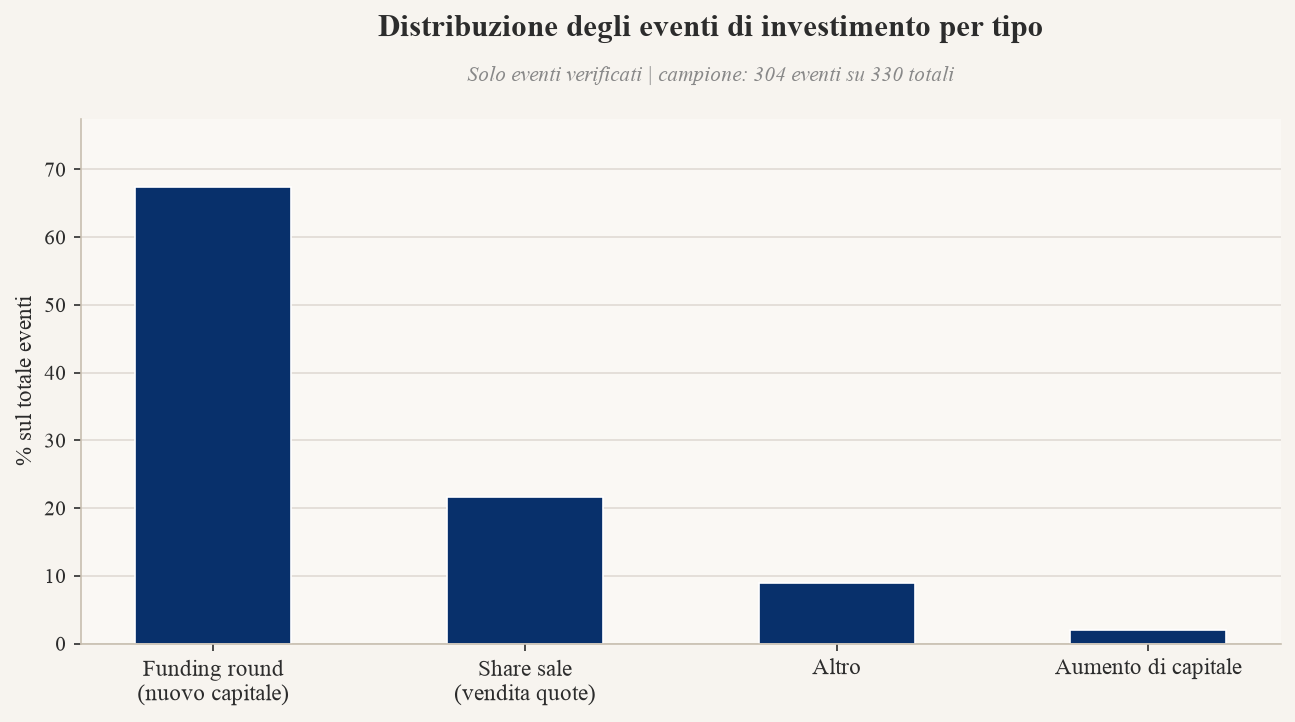

In [16]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd

mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['figure.dpi'] = 150

df = pd.read_excel("/Users/claudiatimis/Desktop/ANALISI STARTUP/storico_investimenti.xlsx")

# ── 1. PULIZIA ───────────────────────────────────────────────
df['is_verified'] = df['Verifica'].str.startswith('verificato')
df_verified = df[df['is_verified']].copy()

label_map = {
    'funding_round':    'Funding round\n(nuovo capitale)',
    'share_sale':       'Share sale\n(vendita quote)',
    'other':            'Altro',
    'capital_increase': 'Aumento di capitale',
}
df_verified['tipo_label'] = df_verified['Tipo Evento'].map(label_map).fillna('Altro')

agg = (
    df_verified.groupby('tipo_label')
    .size()
    .reset_index(name='n')
    .sort_values('n', ascending=False)
    .reset_index(drop=True)
)
agg['pct'] = (agg['n'] / agg['n'].sum() * 100).round(1)

# ── 2. FIGURA ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#f7f4ef')
ax.set_facecolor('#faf8f4')
fig.subplots_adjust(left=0.08, right=0.88, top=0.82, bottom=0.12)

ax.bar(
    agg['tipo_label'],
    agg['pct'],
    color='#08306b',
    edgecolor='white',
    linewidth=0.8,
    width=0.5,
)

# ── 3. STILE ─────────────────────────────────────────────────
fig.text(
    0.5, 0.93,
    'Distribuzione degli eventi di investimento per tipo',
    ha='center', fontsize=15, color='#2c2c2c', fontweight='bold'
)
fig.text(
    0.5, 0.87,
    f'Solo eventi verificati | campione: {len(df_verified)} eventi su {len(df)} totali',
    ha='center', fontsize=10, color='#888888', style='italic'
)

ax.set_ylabel('% sul totale eventi', fontsize=11, color='#2c2c2c')
ax.tick_params(axis='x', labelsize=11, colors='#2c2c2c')
ax.tick_params(axis='y', labelsize=10, colors='#2c2c2c')
ax.set_ylim(0, agg['pct'].max() * 1.15)
ax.yaxis.grid(True, color='#e0dbd4', linewidth=0.8)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#c8bfb0')
ax.spines['bottom'].set_color('#c8bfb0')

plt.show()

### DISTRIBUZIONE DEGLI IMPORT PER FASCIA, SUI FUNDING ROUND VERIFICATI CON IMPORTO DISPONIBILE

Funding round verificati: 205
Di cui con importo disponibile: 189
Senza importo: 16


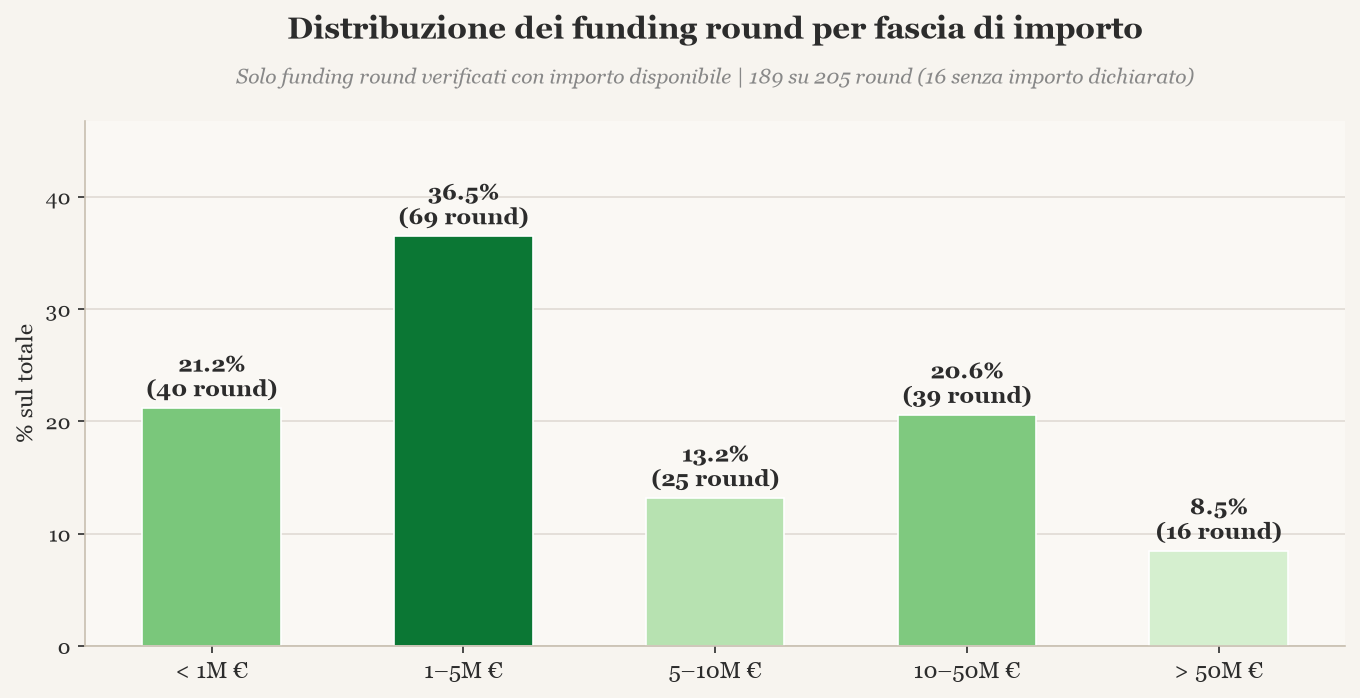

In [17]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np

try:
    fm.findfont('Georgia', rebuild_if_missing=False)
    mpl.rcParams['font.family'] = 'Georgia'
except:
    mpl.rcParams['font.family'] = 'serif'

df = pd.read_excel("/Users/claudiatimis/Desktop/ANALISI STARTUP/storico_investimenti.xlsx")

# ── 1. PULIZIA ───────────────────────────────────────────────
df['is_verified'] = df['Verifica'].str.startswith('verificato')

# Solo funding round verificati con importo disponibile
df_funding = df[
    (df['is_verified']) &
    (df['Tipo Evento'] == 'funding_round') &
    (df['Importo (Mln €)'].notna()) &
    (df['Importo (Mln €)'] > 0)
].copy()

n_tot_funding = df[
    (df['is_verified']) &
    (df['Tipo Evento'] == 'funding_round')
].shape[0]

print(f"Funding round verificati: {n_tot_funding}")
print(f"Di cui con importo disponibile: {len(df_funding)}")
print(f"Senza importo: {n_tot_funding - len(df_funding)}")

# ── 2. FASCE ─────────────────────────────────────────────────
fasce  = [0, 1, 5, 10, 50, float('inf')]
labels = ['< 1M €', '1–5M €', '5–10M €', '10–50M €', '> 50M €']

df_funding['fascia'] = pd.cut(
    df_funding['Importo (Mln €)'],
    bins=fasce,
    labels=labels
)

agg = (
    df_funding.groupby('fascia', observed=True)
    .size()
    .reset_index(name='n')
)
agg['pct'] = (agg['n'] / agg['n'].sum() * 100).round(1)

# ── 3. COLORI — proporzionale alla frequenza ─────────────────
cmap = mpl.colormaps['Greens']
norm = mpl.colors.Normalize(vmin=0, vmax=agg['n'].max() * 1.2)
colori = [cmap(norm(n)) for n in agg['n']]

# ── 4. FIGURA ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#f7f4ef')
ax.set_facecolor('#faf8f4')
fig.subplots_adjust(left=0.08, right=0.92, top=0.82, bottom=0.12)

bars = ax.bar(
    agg['fascia'].astype(str),
    agg['pct'],
    color=colori[:len(agg)],
    edgecolor='white',
    linewidth=0.8,
    width=0.55,
)

# Etichette sopra ogni barra
for bar, (_, row) in zip(bars, agg.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{row['pct']}%\n({int(row['n'])} round)",
        ha='center', va='bottom',
        fontsize=11, color='#2c2c2c', fontweight='bold'
    )

# ── 5. STILE ─────────────────────────────────────────────────
fig.text(
    0.5, 0.93,
    'Distribuzione dei funding round per fascia di importo',
    ha='center', fontsize=15, color='#2c2c2c', fontweight='bold'
)
fig.text(
    0.5, 0.87,
    f'Solo funding round verificati con importo disponibile | '
    f'{len(df_funding)} su {n_tot_funding} round '
    f'({n_tot_funding - len(df_funding)} senza importo dichiarato)',
    ha='center', fontsize=10, color='#888888', style='italic'
)

ax.set_ylabel('% sul totale', fontsize=11, color='#2c2c2c')
ax.set_xlabel('')
ax.tick_params(axis='x', labelsize=11, colors='#2c2c2c')
ax.tick_params(axis='y', labelsize=10, colors='#2c2c2c')
ax.set_ylim(0, agg['pct'].max() * 1.28)
ax.yaxis.grid(True, color='#e0dbd4', linewidth=0.8)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#c8bfb0')
ax.spines['bottom'].set_color('#c8bfb0')

plt.show()

### Versione 2

Funding round verificati: 205
Di cui con importo disponibile: 189
Senza importo: 16


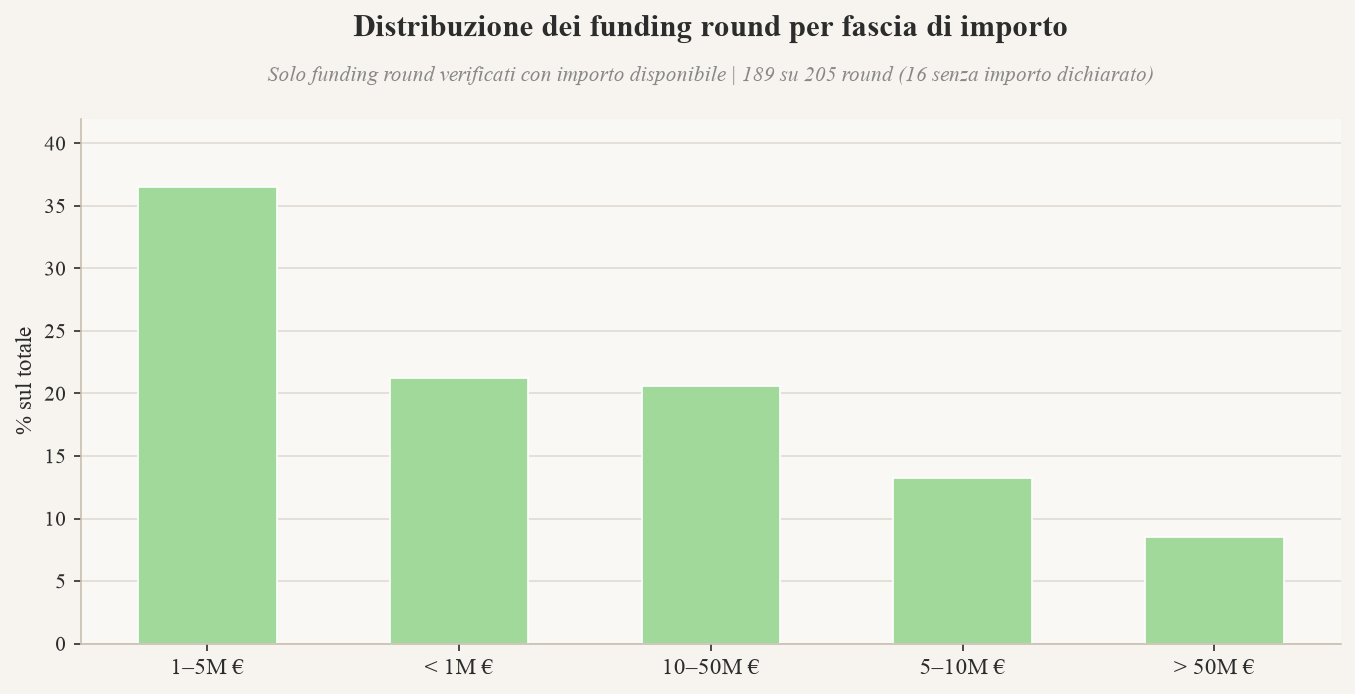

In [18]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd

mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['figure.dpi'] = 150

df = pd.read_excel("/Users/claudiatimis/Desktop/ANALISI STARTUP/storico_investimenti.xlsx")

# ── 1. PULIZIA ───────────────────────────────────────────────
df['is_verified'] = df['Verifica'].str.startswith('verificato')

df_funding = df[
    (df['is_verified']) &
    (df['Tipo Evento'] == 'funding_round') &
    (df['Importo (Mln €)'].notna()) &
    (df['Importo (Mln €)'] > 0)
].copy()

n_tot_funding = df[
    (df['is_verified']) &
    (df['Tipo Evento'] == 'funding_round')
].shape[0]

print(f"Funding round verificati: {n_tot_funding}")
print(f"Di cui con importo disponibile: {len(df_funding)}")
print(f"Senza importo: {n_tot_funding - len(df_funding)}")

# ── 2. FASCE ─────────────────────────────────────────────────
fasce  = [0, 1, 5, 10, 50, float('inf')]
labels = ['< 1M €', '1–5M €', '5–10M €', '10–50M €', '> 50M €']

df_funding['fascia'] = pd.cut(
    df_funding['Importo (Mln €)'],
    bins=fasce,
    labels=labels
)

agg = (
    df_funding.groupby('fascia', observed=True)
    .size()
    .reset_index(name='n')
    .sort_values('n', ascending=False)  # ordine decrescente
    .reset_index(drop=True)
)
agg['pct'] = (agg['n'] / agg['n'].sum() * 100).round(1)

# ── 3. FIGURA ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#f7f4ef')
ax.set_facecolor('#faf8f4')
fig.subplots_adjust(left=0.08, right=0.92, top=0.82, bottom=0.12)

ax.bar(
    agg['fascia'].astype(str),
    agg['pct'],
    color='#a1d99b',
    edgecolor='white',
    linewidth=0.8,
    width=0.55,
)

# ── 4. STILE ─────────────────────────────────────────────────
fig.text(
    0.5, 0.93,
    'Distribuzione dei funding round per fascia di importo',
    ha='center', fontsize=15, color='#2c2c2c', fontweight='bold'
)
fig.text(
    0.5, 0.87,
    f'Solo funding round verificati con importo disponibile | '
    f'{len(df_funding)} su {n_tot_funding} round '
    f'({n_tot_funding - len(df_funding)} senza importo dichiarato)',
    ha='center', fontsize=10, color='#888888', style='italic'
)

ax.set_ylabel('% sul totale', fontsize=11, color='#2c2c2c')
ax.tick_params(axis='x', labelsize=11, colors='#2c2c2c')
ax.tick_params(axis='y', labelsize=10, colors='#2c2c2c')
ax.set_ylim(0, agg['pct'].max() * 1.15)
ax.yaxis.grid(True, color='#e0dbd4', linewidth=0.8)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#c8bfb0')
ax.spines['bottom'].set_color('#c8bfb0')

plt.show()

### DISTRIBUZIONE DELLE STARTUP MULTI - ROUND: QUANTE STARTUP HANNO RACCOLTO PIU DI UNA VOLTA

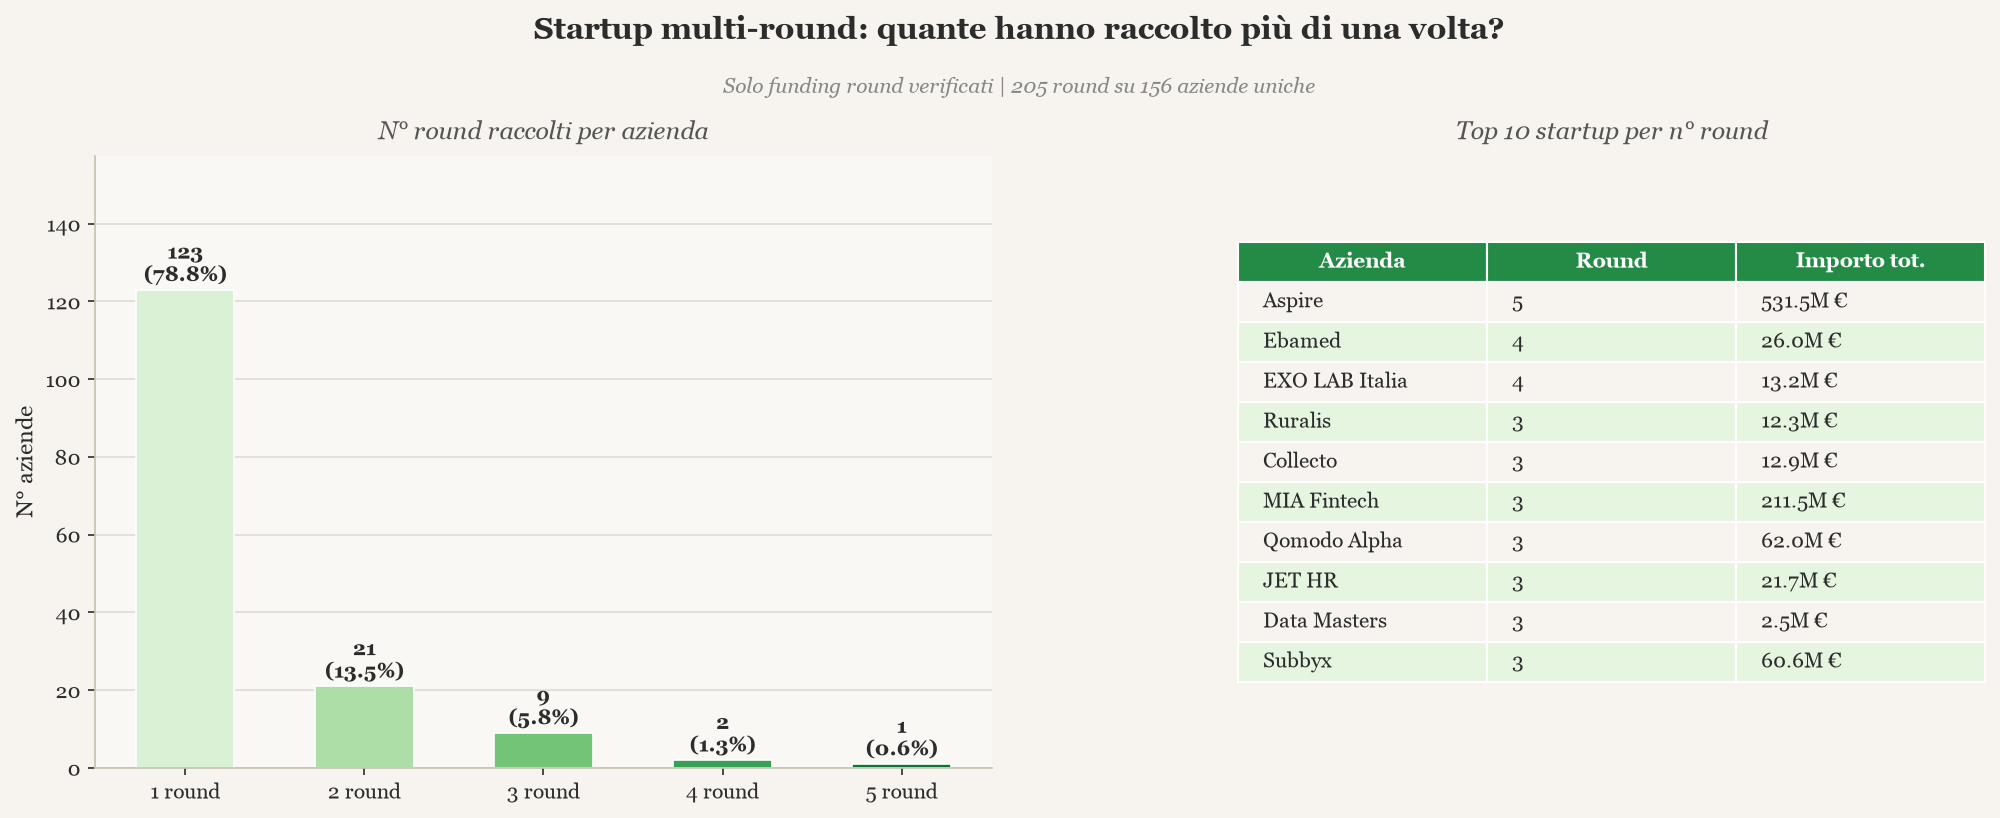

In [19]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm
import pandas as pd

try:
    fm.findfont('Georgia', rebuild_if_missing=False)
    mpl.rcParams['font.family'] = 'Georgia'
except:
    mpl.rcParams['font.family'] = 'serif'

df = pd.read_excel("/Users/claudiatimis/Desktop/ANALISI STARTUP/storico_investimenti.xlsx")

# ── 1. PULIZIA ───────────────────────────────────────────────
df['is_verified'] = df['Verifica'].str.startswith('verificato')
df_funding = df[
    (df['is_verified']) &
    (df['Tipo Evento'] == 'funding_round')
].copy()

round_per_azienda = (
    df_funding.groupby('Azienda')
    .agg(n_round=('Tipo Evento', 'count'))
    .reset_index()
    .sort_values('n_round', ascending=False)
)

dist = (
    round_per_azienda.groupby('n_round')
    .size()
    .reset_index(name='n_aziende')
)
dist['pct'] = (dist['n_aziende'] / dist['n_aziende'].sum() * 100).round(1)

# ── 2. COLORI verde ──────────────────────────────────────────
cmap = mpl.colormaps['Greens']
norm = mpl.colors.Normalize(vmin=0, vmax=dist['n_round'].max() * 1.2)
colori = [cmap(norm(n)) for n in dist['n_round']]

# ── 3. FIGURA ────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6),
                                gridspec_kw={'width_ratios': [1.2, 1]})
fig.patch.set_facecolor('#f7f4ef')
ax1.set_facecolor('#faf8f4')
ax2.set_facecolor('#f7f4ef')
fig.subplots_adjust(left=0.06, right=0.96, top=0.80, bottom=0.12, wspace=0.3)

# ── PANNELLO 1: bar chart ────────────────────────────────────
bars = ax1.bar(
    dist['n_round'].astype(str) + ' round',
    dist['n_aziende'],
    color=colori,
    edgecolor='white',
    linewidth=0.8,
    width=0.55,
)

for bar, (_, row) in zip(bars, dist.iterrows()):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.8,
        f"{int(row['n_aziende'])}\n({row['pct']}%)",
        ha='center', va='bottom',
        fontsize=10, color='#2c2c2c', fontweight='bold'
    )

ax1.set_title('N° round raccolti per azienda',
              fontsize=12, color='#555555', pad=8, style='italic')
ax1.set_ylabel('N° aziende', fontsize=11, color='#2c2c2c')
ax1.set_xlabel('')
ax1.tick_params(labelsize=10, colors='#2c2c2c')
ax1.set_ylim(0, dist['n_aziende'].max() * 1.28)
ax1.yaxis.grid(True, color='#e0dbd4', linewidth=0.8)
ax1.set_axisbelow(True)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_color('#c8bfb0')
ax1.spines['bottom'].set_color('#c8bfb0')

# ── PANNELLO 2: tabella ──────────────────────────────────────
top10 = round_per_azienda.head(10).copy()
importo_per_azienda = df_funding.groupby('Azienda')['Importo (Mln €)'].sum()
top10['importo_fmt'] = top10['Azienda'].map(importo_per_azienda).apply(
    lambda x: f"{x:.1f}M €" if pd.notna(x) else "n.d."
)

ax2.axis('off')
ax2.set_title('Top 10 startup per n° round',
              fontsize=12, color='#555555', pad=8, style='italic')

table_data = [[row['Azienda'], int(row['n_round']), row['importo_fmt']]
              for _, row in top10.iterrows()]

table = ax2.table(
    cellText=table_data,
    colLabels=['Azienda', 'Round', 'Importo tot.'],
    loc='center',
    cellLoc='left',
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.6)

# Stile header verde
for j in range(3):
    table[0, j].set_facecolor('#238b45')
    table[0, j].set_text_props(color='white', fontweight='bold')
    table[0, j].set_edgecolor('white')

# Righe alternate verde chiaro
for i in range(1, len(table_data) + 1):
    for j in range(3):
        table[i, j].set_facecolor('#e5f5e0' if i % 2 == 0 else '#f7f4ef')
        table[i, j].set_edgecolor('white')
        table[i, j].set_text_props(color='#2c2c2c')

# ── 4. TITOLO E SOTTOTITOLO ───────────────────────────────────
fig.text(
    0.5, 0.93,
    'Startup multi-round: quante hanno raccolto più di una volta?',
    ha='center', fontsize=15, color='#2c2c2c', fontweight='bold'
)
fig.text(
    0.5, 0.87,
    f'Solo funding round verificati | {len(df_funding)} round su '
    f'{round_per_azienda["Azienda"].nunique()} aziende uniche',
    ha='center', fontsize=10, color='#888888', style='italic'
)

plt.show()

### Versione 2

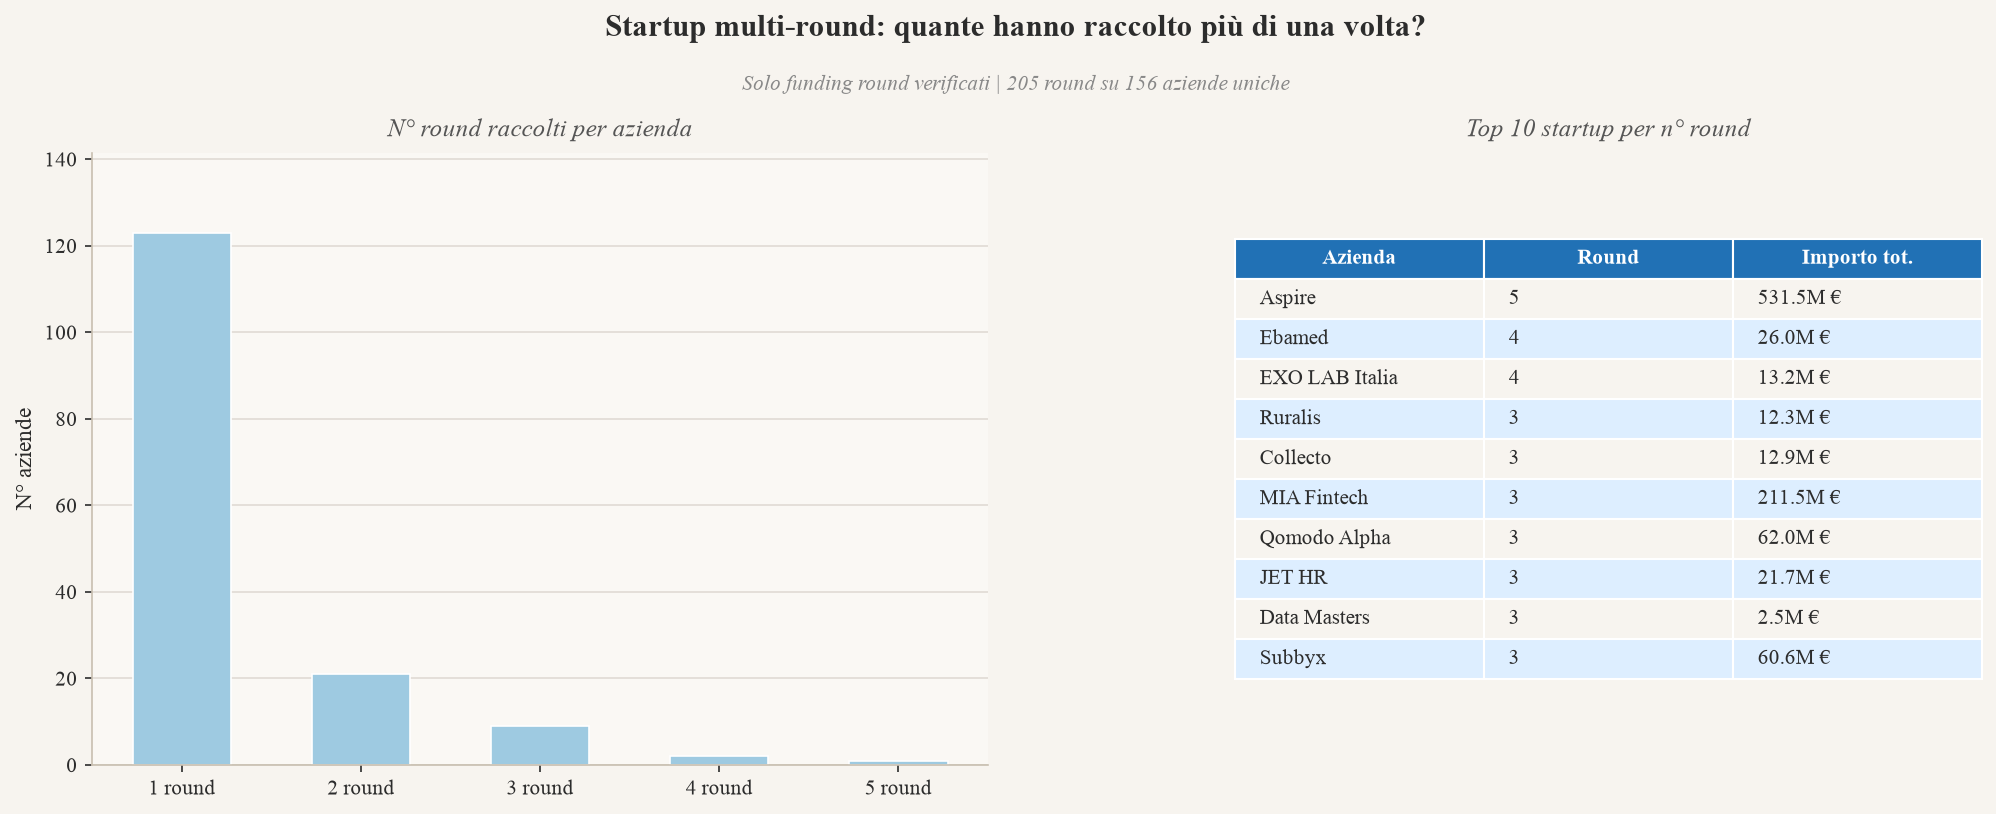

In [20]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd

mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['figure.dpi'] = 150

df = pd.read_excel("/Users/claudiatimis/Desktop/ANALISI STARTUP/storico_investimenti.xlsx")

# ── 1. PULIZIA ───────────────────────────────────────────────
df['is_verified'] = df['Verifica'].str.startswith('verificato')
df_funding = df[
    (df['is_verified']) &
    (df['Tipo Evento'] == 'funding_round')
].copy()

round_per_azienda = (
    df_funding.groupby('Azienda')
    .agg(n_round=('Tipo Evento', 'count'))
    .reset_index()
    .sort_values('n_round', ascending=False)
)

dist = (
    round_per_azienda.groupby('n_round')
    .size()
    .reset_index(name='n_aziende')
)
dist['pct'] = (dist['n_aziende'] / dist['n_aziende'].sum() * 100).round(1)

# ── 2. FIGURA ────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6),
                                gridspec_kw={'width_ratios': [1.2, 1]})
fig.patch.set_facecolor('#f7f4ef')
ax1.set_facecolor('#faf8f4')
ax2.set_facecolor('#f7f4ef')
fig.subplots_adjust(left=0.06, right=0.96, top=0.80, bottom=0.12, wspace=0.3)

# ── PANNELLO 1: bar chart ────────────────────────────────────
ax1.bar(
    dist['n_round'].astype(str) + ' round',
    dist['n_aziende'],
    color='#9ecae1',
    edgecolor='white',
    linewidth=0.8,
    width=0.55,
)

ax1.set_title('N° round raccolti per azienda',
              fontsize=12, color='#555555', pad=8, style='italic')
ax1.set_ylabel('N° aziende', fontsize=11, color='#2c2c2c')
ax1.tick_params(labelsize=10, colors='#2c2c2c')
ax1.set_ylim(0, dist['n_aziende'].max() * 1.15)
ax1.yaxis.grid(True, color='#e0dbd4', linewidth=0.8)
ax1.set_axisbelow(True)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_color('#c8bfb0')
ax1.spines['bottom'].set_color('#c8bfb0')

# ── PANNELLO 2: tabella ──────────────────────────────────────
top10 = round_per_azienda.head(10).copy()
importo_per_azienda = df_funding.groupby('Azienda')['Importo (Mln €)'].sum()
top10['importo_fmt'] = top10['Azienda'].map(importo_per_azienda).apply(
    lambda x: f"{x:.1f}M €" if pd.notna(x) else "n.d."
)

ax2.axis('off')
ax2.set_title('Top 10 startup per n° round',
              fontsize=12, color='#555555', pad=8, style='italic')

table_data = [[row['Azienda'], int(row['n_round']), row['importo_fmt']]
              for _, row in top10.iterrows()]

table = ax2.table(
    cellText=table_data,
    colLabels=['Azienda', 'Round', 'Importo tot.'],
    loc='center',
    cellLoc='left',
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.6)

for j in range(3):
    table[0, j].set_facecolor('#2171b5')
    table[0, j].set_text_props(color='white', fontweight='bold')
    table[0, j].set_edgecolor('white')

for i in range(1, len(table_data) + 1):
    for j in range(3):
        table[i, j].set_facecolor('#ddeeff' if i % 2 == 0 else '#f7f4ef')
        table[i, j].set_edgecolor('white')
        table[i, j].set_text_props(color='#2c2c2c')

# ── 3. TITOLO E SOTTOTITOLO ───────────────────────────────────
fig.text(
    0.5, 0.93,
    'Startup multi-round: quante hanno raccolto più di una volta?',
    ha='center', fontsize=15, color='#2c2c2c', fontweight='bold'
)
fig.text(
    0.5, 0.87,
    f'Solo funding round verificati | {len(df_funding)} round su '
    f'{round_per_azienda["Azienda"].nunique()} aziende uniche',
    ha='center', fontsize=10, color='#888888', style='italic'
)

plt.show()

### NETWORK DEI CO-INVESTITORI

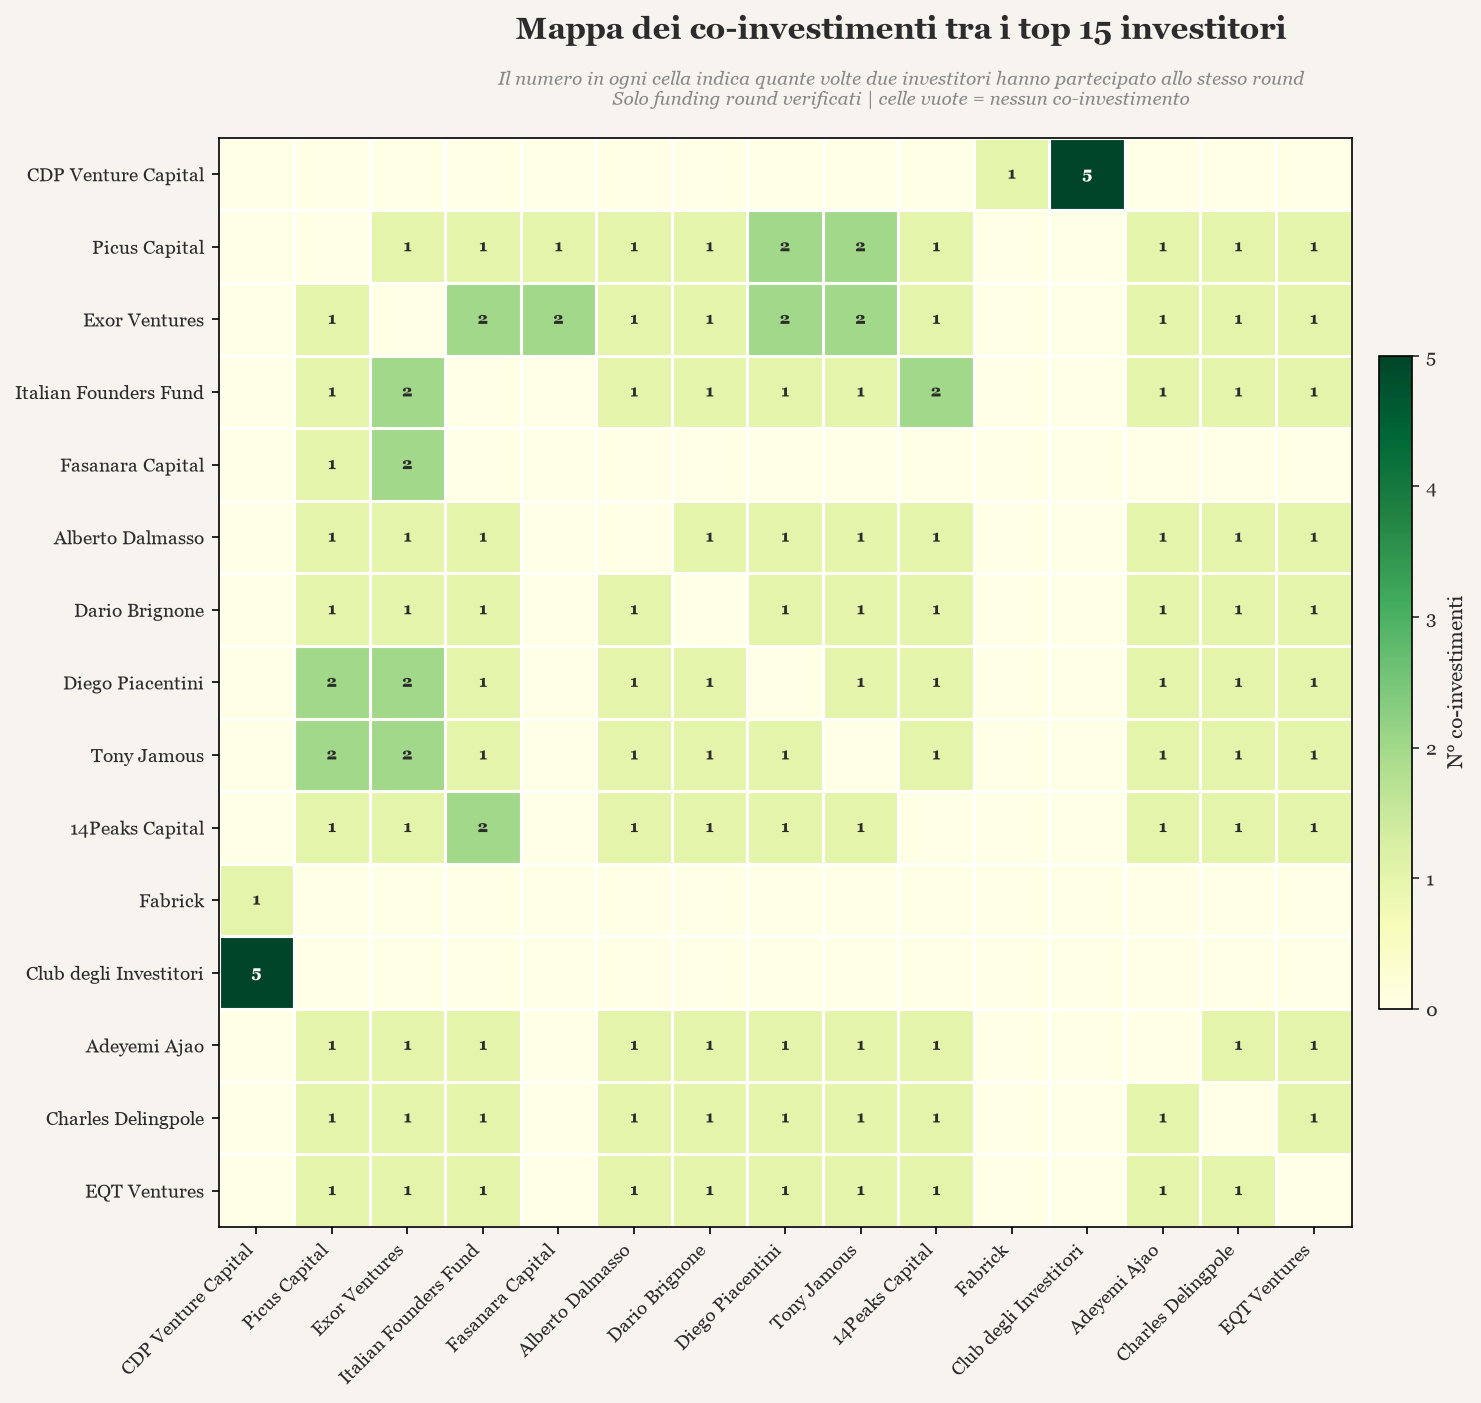

In [21]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm
import pandas as pd
import itertools
import numpy as np

try:
    fm.findfont('Georgia', rebuild_if_missing=False)
    mpl.rcParams['font.family'] = 'Georgia'
except:
    mpl.rcParams['font.family'] = 'serif'

df = pd.read_excel("/Users/claudiatimis/Desktop/ANALISI STARTUP/storico_investimenti.xlsx")

# ── 1. PULIZIA ───────────────────────────────────────────────
df['is_verified'] = df['Verifica'].str.startswith('verificato')
df_funding = df[
    (df['is_verified']) &
    (df['Tipo Evento'] == 'funding_round') &
    (df['Investitori'].notna())
].copy()

normalize_map = {
    'CDP Venture Capital':             'CDP Venture Capital',
    'Cdp Venture Capital':             'CDP Venture Capital',
    'CDP Venture Capital SGR':         'CDP Venture Capital',
    'Club degli investitori':          'Club degli Investitori',
    'Club degli Investitori':          'Club degli Investitori',
    'Italian angels for growth (IAG)': 'IAG',
    'iN3 Ventures':                    'iN3 Ventures',
    'ITA500':                          'ITA500',
    'Club Italia investimenti 2':      'Club Italia Inv. 2',
    'Club Italia Investimenti 2':      'Club Italia Inv. 2',
    "Fondo Italiano d'Investimento":   "Fondo It. d'Inv.",
    "Fondo Italiano D'Investimento":   "Fondo It. d'Inv.",
}

df_funding['inv_list'] = df_funding['Investitori'].str.split(',').apply(
    lambda x: [normalize_map.get(i.strip(), i.strip())
               for i in x if i.strip() not in ('', 'Country')]
)

# ── 2. COSTRUISCI EDGE LIST ──────────────────────────────────
edges = []
for _, row in df_funding.iterrows():
    invs = row['inv_list']
    if len(invs) > 1:
        for a, b in itertools.combinations(invs, 2):
            edges.append((a, b))

edge_df = pd.DataFrame(edges, columns=['source', 'target'])
edge_counts = (
    edge_df.groupby(['source', 'target'])
    .size()
    .reset_index(name='weight')
)

# ── 3. TOP 15 NODI ───────────────────────────────────────────
all_nodes = pd.concat([edge_counts['source'], edge_counts['target']])
top15_nodes = all_nodes.value_counts().head(15).index.tolist()

# ── 4. MATRICE DI CO-INVESTIMENTO ────────────────────────────
matrix = pd.DataFrame(0, index=top15_nodes, columns=top15_nodes)

for _, row in edge_counts.iterrows():
    if row['source'] in top15_nodes and row['target'] in top15_nodes:
        matrix.loc[row['source'], row['target']] = row['weight']
        matrix.loc[row['target'], row['source']] = row['weight']

# ── FIX: copia esplicita prima di fill_diagonal ──────────────
matrix_arr = matrix.to_numpy(dtype=float, copy=True)
np.fill_diagonal(matrix_arr, 0)

# ── 5. FIGURA ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 11))
fig.patch.set_facecolor('#f7f4ef')
ax.set_facecolor('#f7f4ef')
fig.subplots_adjust(left=0.22, right=0.92, top=0.88, bottom=0.22)

cmap = mpl.colormaps['YlGn']
im = ax.imshow(matrix_arr, cmap=cmap, aspect='auto')

# Colorbar
cbar = fig.colorbar(im, ax=ax, shrink=0.6, pad=0.02)
cbar.set_label('N° co-investimenti', fontsize=10, color='#2c2c2c')
cbar.ax.tick_params(labelsize=9, colors='#2c2c2c')

# Etichette assi
ax.set_xticks(range(len(top15_nodes)))
ax.set_yticks(range(len(top15_nodes)))
ax.set_xticklabels(top15_nodes, rotation=45, ha='right',
                   fontsize=9, color='#2c2c2c')
ax.set_yticklabels(top15_nodes, fontsize=9, color='#2c2c2c')

# Valori nelle celle (solo se > 0)
for i in range(len(top15_nodes)):
    for j in range(len(top15_nodes)):
        val = matrix_arr[i, j]
        if val > 0:
            ax.text(j, i, str(int(val)),
                    ha='center', va='center',
                    fontsize=8,
                    color='white' if val > matrix_arr.max() * 0.5 else '#2c2c2c',
                    fontweight='bold')

# Griglia leggera
ax.set_xticks(np.arange(-0.5, len(top15_nodes), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(top15_nodes), 1), minor=True)
ax.grid(which='minor', color='white', linewidth=1.5)
ax.tick_params(which='minor', bottom=False, left=False)

# ── 6. STILE ─────────────────────────────────────────────────
fig.text(
    0.57, 0.94,
    'Mappa dei co-investimenti tra i top 15 investitori',
    ha='center', fontsize=15, color='#2c2c2c', fontweight='bold'
)
fig.text(
    0.57, 0.90,
    'Il numero in ogni cella indica quante volte due investitori hanno partecipato allo stesso round\n'
    'Solo funding round verificati | celle vuote = nessun co-investimento',
    ha='center', fontsize=9, color='#888888', style='italic'
)

plt.show()

### Versione 2

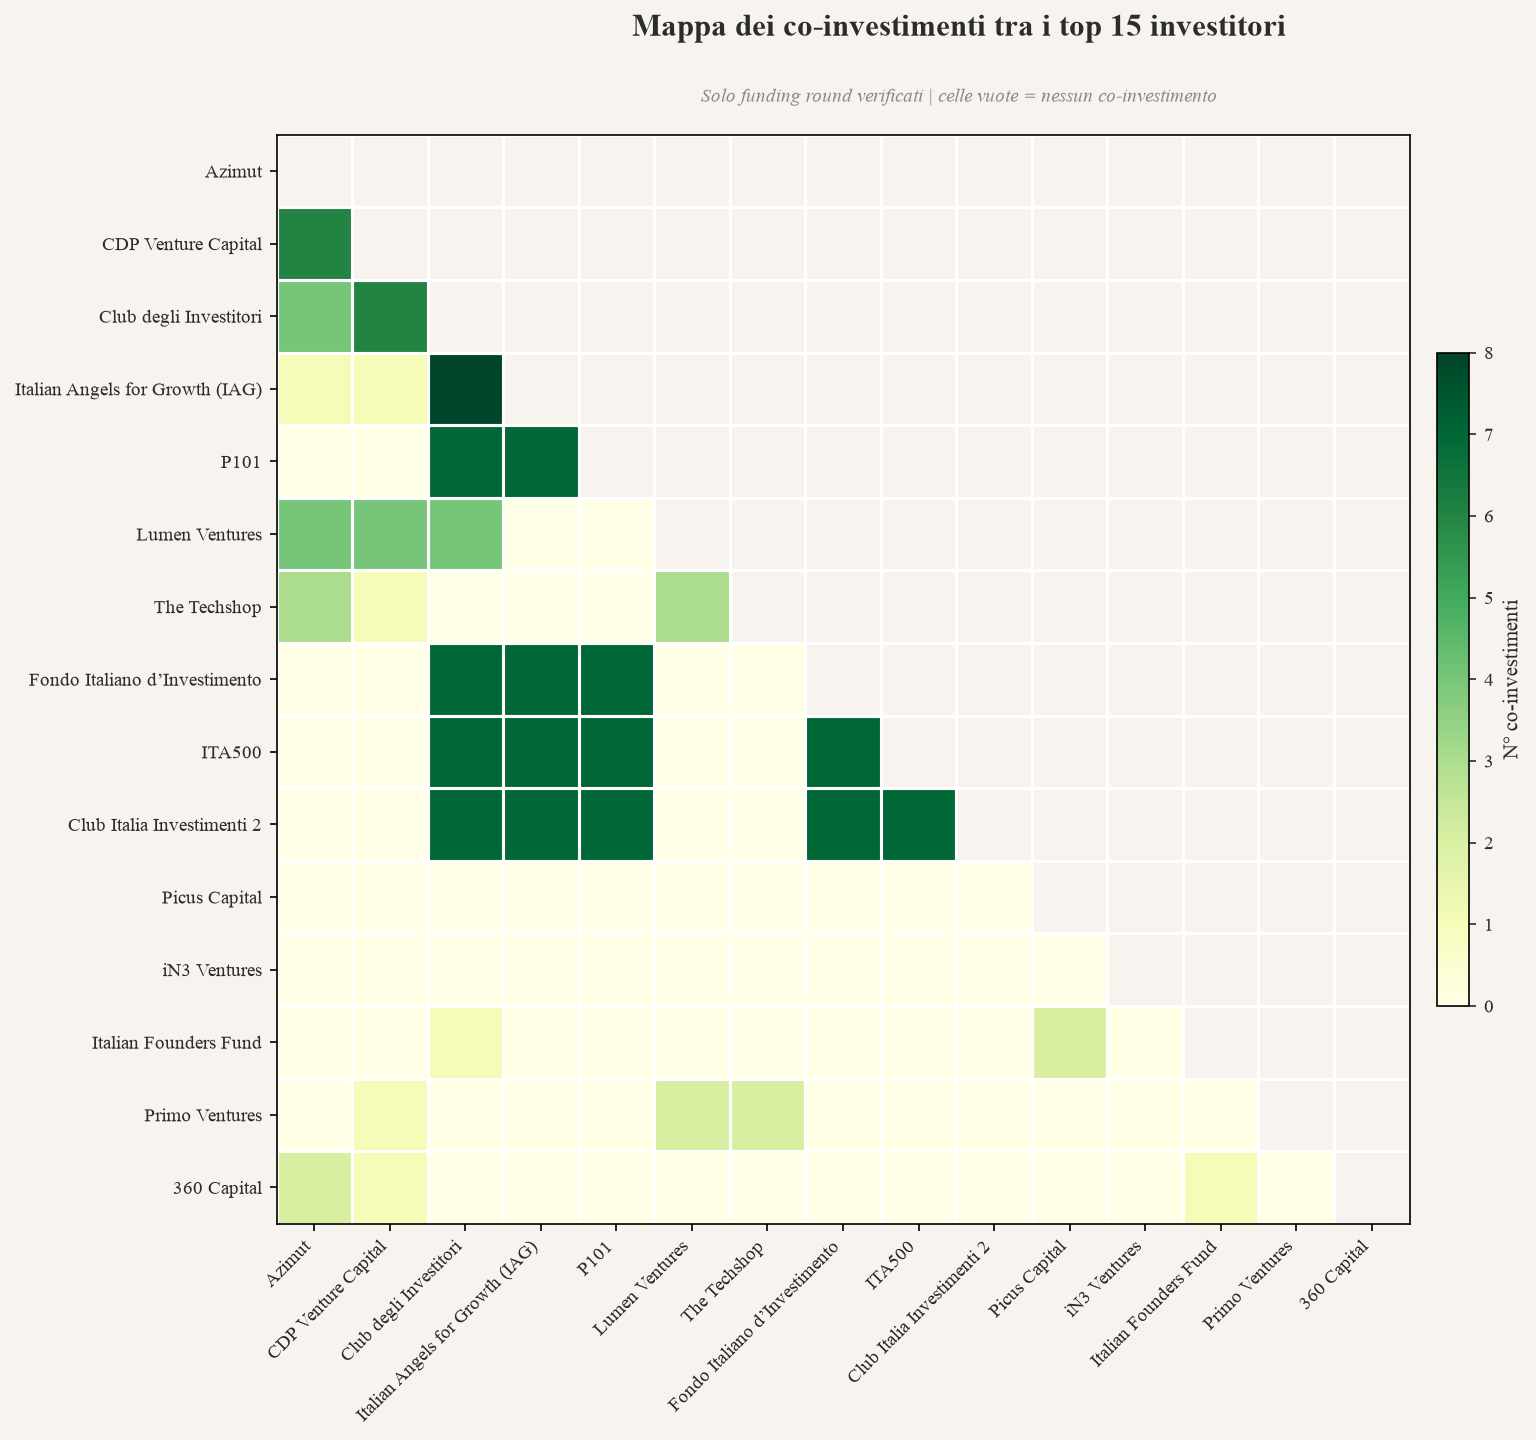

In [22]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import itertools
import numpy as np

mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['figure.dpi'] = 150

df = pd.read_excel("/Users/claudiatimis/Desktop/ANALISI STARTUP/storico_investimenti.xlsx")

# ── 1. PULIZIA ───────────────────────────────────────────────
df['is_verified'] = df['Verifica'].str.startswith('verificato')
df_funding = df[
    (df['is_verified']) &
    (df['Tipo Evento'] == 'funding_round') &
    (df['Investitori'].notna())
].copy()

# Stesso normalize_map del grafico top 15
normalize_map = {
    'CDP Venture Capital':                                'CDP Venture Capital',
    'Cdp Venture Capital':                                'CDP Venture Capital',
    'CDP Venture Capital SGR':                            'CDP Venture Capital',
    'CDP Venture Capital Sgr':                            'CDP Venture Capital',
    'CDP VC':                                             'CDP Venture Capital',
    'Artificial Intelligence Fund of CDP Venture Capital':'CDP Venture Capital',
    'Club degli Investitori':                             'Club degli Investitori',
    'Club degli investitori':                             'Club degli Investitori',
    'Club Degli Investitori':                             'Club degli Investitori',
    'Italian angels for growth (IAG)':                   'Italian Angels for Growth (IAG)',
    'Italian Angels for Growth':                          'Italian Angels for Growth (IAG)',
    'Italian Founders Fund (IFF)':                        'Italian Founders Fund',
    'IFF':                                                'Italian Founders Fund',
    'iN3 Ventures':                                       'iN3 Ventures',
    'In3 Ventures':                                       'iN3 Ventures',
    'ITA500':                                             'ITA500',
    'Ita500':                                             'ITA500',
    "Fondo Italiano d'Investimento":                      "Fondo Italiano d'Investimento",
    "Fondo Italiano D'Investimento":                      "Fondo Italiano d'Investimento",
    "Fondo Italiano d'Investimento SGR":                  "Fondo Italiano d'Investimento",
    'Club Italia investimenti 2':                         'Club Italia Investimenti 2',
    'Club Italia Investimenti 2':                         'Club Italia Investimenti 2',
    'Azimut':                                             'Azimut',
    'Azimut Digitech Fund':                               'Azimut',
    'Azimut Libera Impresa':                              'Azimut',
    'Azimut Libera Impresa sgr':                          'Azimut',
    'Azimut Libera Impresa SGR':                          'Azimut',
    'Azimut Venture Capital Digitech Europe':             'Azimut',
    'Azimut Eltif-Venture Capital Alicrowd III':          'Azimut',
    'Azimut Eltif-Venture Capital Alicrowd IV':           'Azimut',
    'Azimut Eltif':                                       'Azimut',
    'Venture Capital Alicrowd II':                        'Azimut',
    'AZIMUT ELTIF – Venture Capital ALIcrowd III and IV': 'Azimut',
    'AZIMUT ELTIF – Venture Capital ALIcrowd II':         'Azimut',
    'Gruppo Azimut':                                      'Azimut',
    'Gellify/Digitech Fund':                              'Azimut',
    'The Techshop':                                       'The Techshop',
    'The Techshop SGR':                                   'The Techshop',
    'echshop SGR':                                        'The Techshop',
    'P101':                                               'P101',
    'P101 SGR':                                           'P101',
    'Plug and Play Tech Center':                          'Plug and Play',
    'Plug and Play Ventures':                             'Plug and Play',
    'Plug & Play Tech Center':                            'Plug and Play',
    'RTP Global':                                         'RTP Global',
    'Rtp Global':                                         'RTP Global',
    'Primo Capital':                                      'Primo Ventures',
    'Primo Ventures':                                     'Primo Ventures',
    'Advent International':                               'Advent International',
    'Advent International L.P.':                          'Advent International',
    'FG2 Capital':                                        'FG2 Capital',
    'Fg2 Capital':                                        'FG2 Capital',
    'LMDV Capital':                                       'LMDV Capital',
    'Lmdv Capital':                                       'LMDV Capital',
    'Mass Mutual Ventures':                               'MassMutual Ventures',
    'MassMutual Ventures Southeast Asia':                 'MassMutual Ventures',
    'MassMutual Ventures':                                'MassMutual Ventures',
    'Itacha Investments':                                 'Ithaca Investment',
    'Ithaca Investment':                                  'Ithaca Investment',
    'Exor Seeds           Seed':                          'Exor Seeds',
    'Exor Seeds':                                         'Exor Seeds',
    '40Jemz Ventures':                                    '40Jemz',
    '40Jemz':                                             '40Jemz',
    'LVenture':                                           'LVenture Group',
    'LVenture Group':                                     'LVenture Group',
    'Vertis':                                             'Vertis SGR',
    'Vertis SGR':                                         'Vertis SGR',
    'PranaVentures':                                      'Prana Ventures',
    'Prana Ventures':                                     'Prana Ventures',
    'LA4G - Luiss Alumni for Growth':                     'La4G',
    'La4G':                                               'La4G',
    'Hummingbird':                                        'Hummingbird Ventures',
    'Hummingbird Ventures':                               'Hummingbird Ventures',
    'Lightspeed':                                         'Lightspeed Venture Partners',
    'Lightspeed Venture Partners':                        'Lightspeed Venture Partners',
    'Pitchdrive':                                         'PitchDrive',
    'PitchDrive':                                         'PitchDrive',
    'a16z':                                               'Andreessen Horowitz',
    'Andreessen Horowitz':                                'Andreessen Horowitz',
    'Wise3':                                              'Wise3 Ventures',
    'Wise3 Ventures':                                     'Wise3 Ventures',
    'Foreign':                                            None,
    'Seed':                                               None,
    'See':                                                None,
    'Star':                                               None,
    'Sta':                                                None,
    'S':                                                  None,
    'Se':                                                 None,
    'Country':                                            None,
    'business angel':                                     None,
    'business angels':                                    None,
    'angel investor':                                     None,
    'family office':                                      None,
    'investitori USA':                                    None,
    'international business angels':                      None,
    'business angel italiani e internazionali':           None,
    'altri fondi di venture capital':                     None,
    'imprenditori internazionali nel settore tech':       None,
    'a group of private investors':                       None,
    'five third-party investors':                         None,
    'other undisclosed institutional and private investors': None,
    '~30 investitori istituzionali':                      None,
    'gruppo di investitori privati':                      None,
    '175 investors':                                      None,
    '1 Other investor':                                   None,
    '8831356':                                            None,
    '5852643':                                            None,
    '8746202':                                            None,
    '3839674':                                            None,
    '2302':                                               None,
    '8228':                                               None,
}

df_funding['inv_list'] = df_funding['Investitori'].str.split(',').apply(
    lambda x: [
        normalize_map.get(i.strip(), i.strip())
        for i in x
        if i.strip() not in ('', 'Country')
        and normalize_map.get(i.strip(), i.strip()) is not None
    ]
)

# ── 2. EDGE LIST ─────────────────────────────────────────────
edges = []
for _, row in df_funding.iterrows():
    invs = row['inv_list']
    if len(invs) > 1:
        for a, b in itertools.combinations(invs, 2):
            edges.append((a, b))

edge_df = pd.DataFrame(edges, columns=['source', 'target'])
edge_counts = (
    edge_df.groupby(['source', 'target'])
    .size()
    .reset_index(name='weight')
)

# ── 3. TOP 15 NODI — stessi del grafico bar ──────────────────
all_investors = (
    df_funding['inv_list']
    .explode()
    .dropna()
)
top15_nodes = all_investors.value_counts().head(15).index.tolist()

# ── 4. MATRICE ───────────────────────────────────────────────
matrix = pd.DataFrame(0, index=top15_nodes, columns=top15_nodes)
for _, row in edge_counts.iterrows():
    if row['source'] in top15_nodes and row['target'] in top15_nodes:
        matrix.loc[row['source'], row['target']] = row['weight']
        matrix.loc[row['target'], row['source']] = row['weight']

matrix_arr = matrix.to_numpy(dtype=float, copy=True)
np.fill_diagonal(matrix_arr, 0)

# ── 5. MASCHERA TRIANGOLO SUPERIORE ──────────────────────────
mask = np.triu(np.ones_like(matrix_arr, dtype=bool), k=0)
matrix_masked = np.where(mask, np.nan, matrix_arr)

# ── 6. FIGURA ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 11))
fig.patch.set_facecolor('#f7f4ef')
ax.set_facecolor('#f7f4ef')
fig.subplots_adjust(left=0.22, right=0.92, top=0.88, bottom=0.22)

cmap = mpl.colormaps['YlGn'].copy()
cmap.set_bad(color='#f7f4ef')

im = ax.imshow(matrix_masked, cmap=cmap, aspect='auto')

cbar = fig.colorbar(im, ax=ax, shrink=0.6, pad=0.02)
cbar.set_label('N° co-investimenti', fontsize=10, color='#2c2c2c')
cbar.ax.tick_params(labelsize=9, colors='#2c2c2c')

ax.set_xticks(range(len(top15_nodes)))
ax.set_yticks(range(len(top15_nodes)))
ax.set_xticklabels(top15_nodes, rotation=45, ha='right',
                   fontsize=9, color='#2c2c2c')
ax.set_yticklabels(top15_nodes, fontsize=9, color='#2c2c2c')

ax.set_xticks(np.arange(-0.5, len(top15_nodes), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(top15_nodes), 1), minor=True)
ax.grid(which='minor', color='white', linewidth=1.5)
ax.tick_params(which='minor', bottom=False, left=False)

# ── 7. TITOLI ─────────────────────────────────────────────────
fig.text(
    0.57, 0.94,
    'Mappa dei co-investimenti tra i top 15 investitori',
    ha='center', fontsize=15, color='#2c2c2c', fontweight='bold'
)
fig.text(
    0.57, 0.90,
    'Solo funding round verificati | celle vuote = nessun co-investimento',
    ha='center', fontsize=9, color='#888888', style='italic'
)

plt.show()

I co-investimenti vengono calcolati così:

Per ogni round, si guarda la lista degli investitori che vi hanno partecipato insieme. Se in un round ci sono ad esempio [CDP Venture Capital, Lumen Ventures, P101], si generano tutte le coppie possibili:

CDP + Lumen
CDP + P101
Lumen + P101

Questo si fa con itertools.combinations(invs, 2) — genera tutte le coppie senza ripetizioni.

Poi si contano quante volte ogni coppia appare in round diversi con groupby(['source', 'target']).size(). Se CDP e Lumen compaiono insieme in 3 round diversi, la cella della heatmap vale 3.

Cosa significa concretamente: il numero in cella non è "quanto hanno investito insieme" in termini di capitale, ma quante volte hanno co-partecipato allo stesso round nel dataset.

### TOP STARTUP PER CAPITALE RACCOLTO

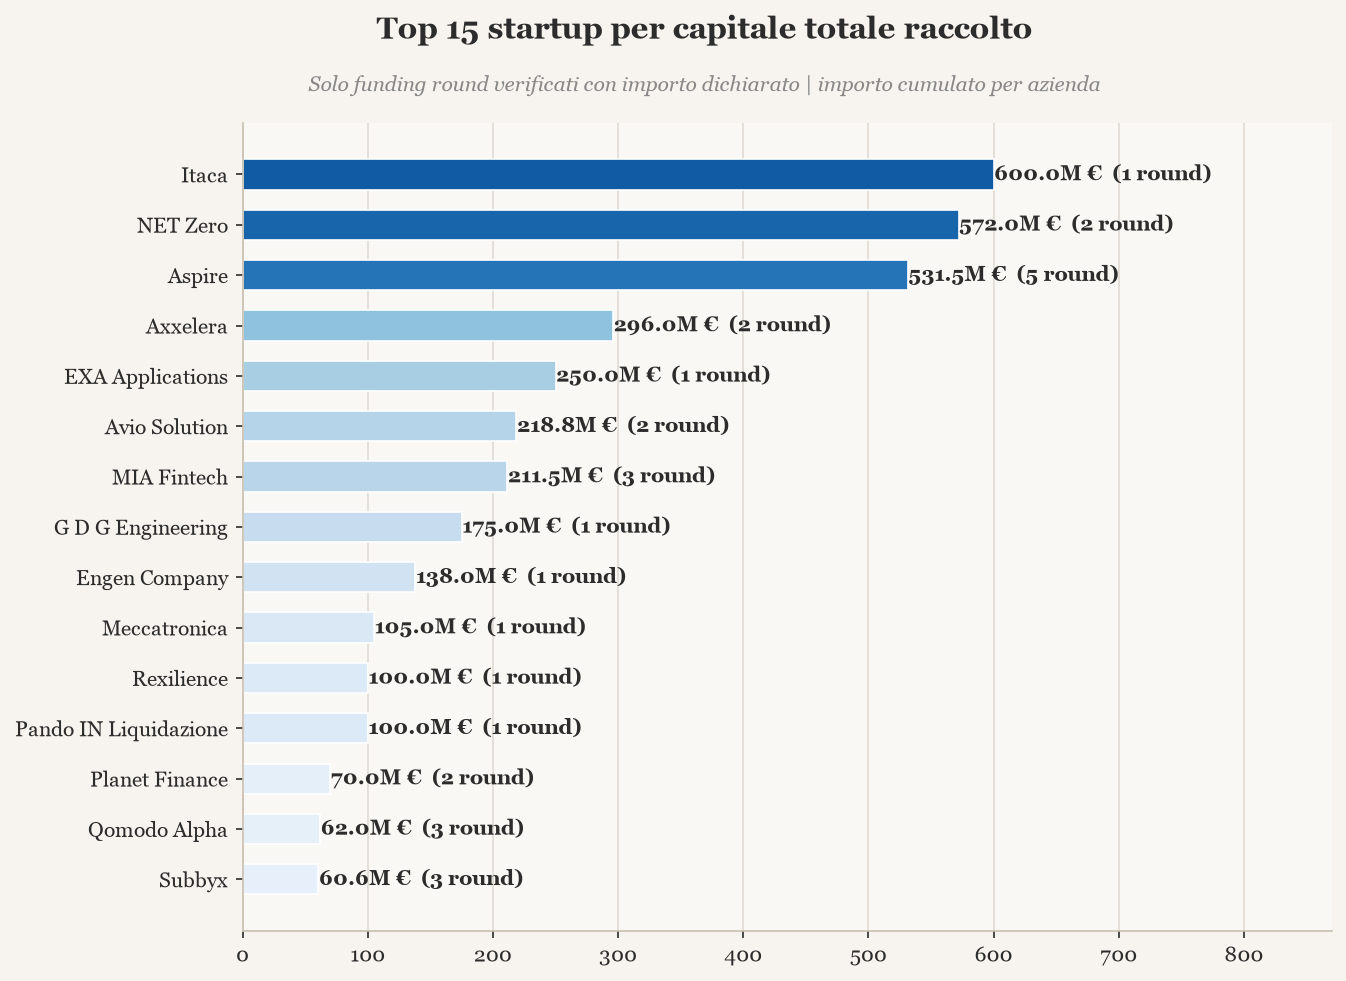

In [23]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm
import pandas as pd

try:
    fm.findfont('Georgia', rebuild_if_missing=False)
    mpl.rcParams['font.family'] = 'Georgia'
except:
    mpl.rcParams['font.family'] = 'serif'

df = pd.read_excel("/Users/claudiatimis/Desktop/ANALISI STARTUP/storico_investimenti.xlsx")

# ── 1. PULIZIA ───────────────────────────────────────────────
df['is_verified'] = df['Verifica'].str.startswith('verificato')
df_funding = df[
    (df['is_verified']) &
    (df['Tipo Evento'] == 'funding_round') &
    (df['Importo (Mln €)'].notna())
].copy()

# Aggrega per azienda
top_startup = (
    df_funding.groupby('Azienda')
    .agg(
        importo_totale=('Importo (Mln €)', 'sum'),
        n_round=('Tipo Evento', 'count'),
    )
    .reset_index()
    .sort_values('importo_totale', ascending=True)
    .tail(15)
    .reset_index(drop=True)
)

top_startup['importo_fmt'] = top_startup['importo_totale'].apply(
    lambda x: f"{x:.1f}M €"
)

# ── 2. COLORI ────────────────────────────────────────────────
cmap = mpl.colormaps['Blues']
norm = mpl.colors.Normalize(
    vmin=0, vmax=top_startup['importo_totale'].max() * 1.2
)
colori = [cmap(norm(n)) for n in top_startup['importo_totale']]

# ── 3. FIGURA ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor('#f7f4ef')
ax.set_facecolor('#faf8f4')
fig.subplots_adjust(left=0.22, right=0.88, top=0.85, bottom=0.08)

bars = ax.barh(
    top_startup['Azienda'],
    top_startup['importo_totale'],
    color=colori,
    edgecolor='white',
    linewidth=0.8,
    height=0.6,
)

# Etichette a destra
for bar, (_, row) in zip(bars, top_startup.iterrows()):
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{row['importo_fmt']}  ({int(row['n_round'])} round)",
        va='center', ha='left',
        fontsize=10, color='#2c2c2c', fontweight='bold'
    )

# ── 4. STILE ─────────────────────────────────────────────────
fig.text(
    0.5, 0.93,
    'Top 15 startup per capitale totale raccolto',
    ha='center', fontsize=15, color='#2c2c2c', fontweight='bold'
)
fig.text(
    0.5, 0.88,
    'Solo funding round verificati con importo dichiarato | importo cumulato per azienda',
    ha='center', fontsize=10, color='#888888', style='italic'
)

ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='y', labelsize=10, colors='#2c2c2c')
ax.tick_params(axis='x', labelsize=10, colors='#2c2c2c')
ax.set_xlim(0, top_startup['importo_totale'].max() * 1.45)
ax.xaxis.grid(True, color='#e0dbd4', linewidth=0.8)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#c8bfb0')
ax.spines['bottom'].set_color('#c8bfb0')

plt.show()

### CAPITALE INVESTIMENTO PER MACRO SETTORE

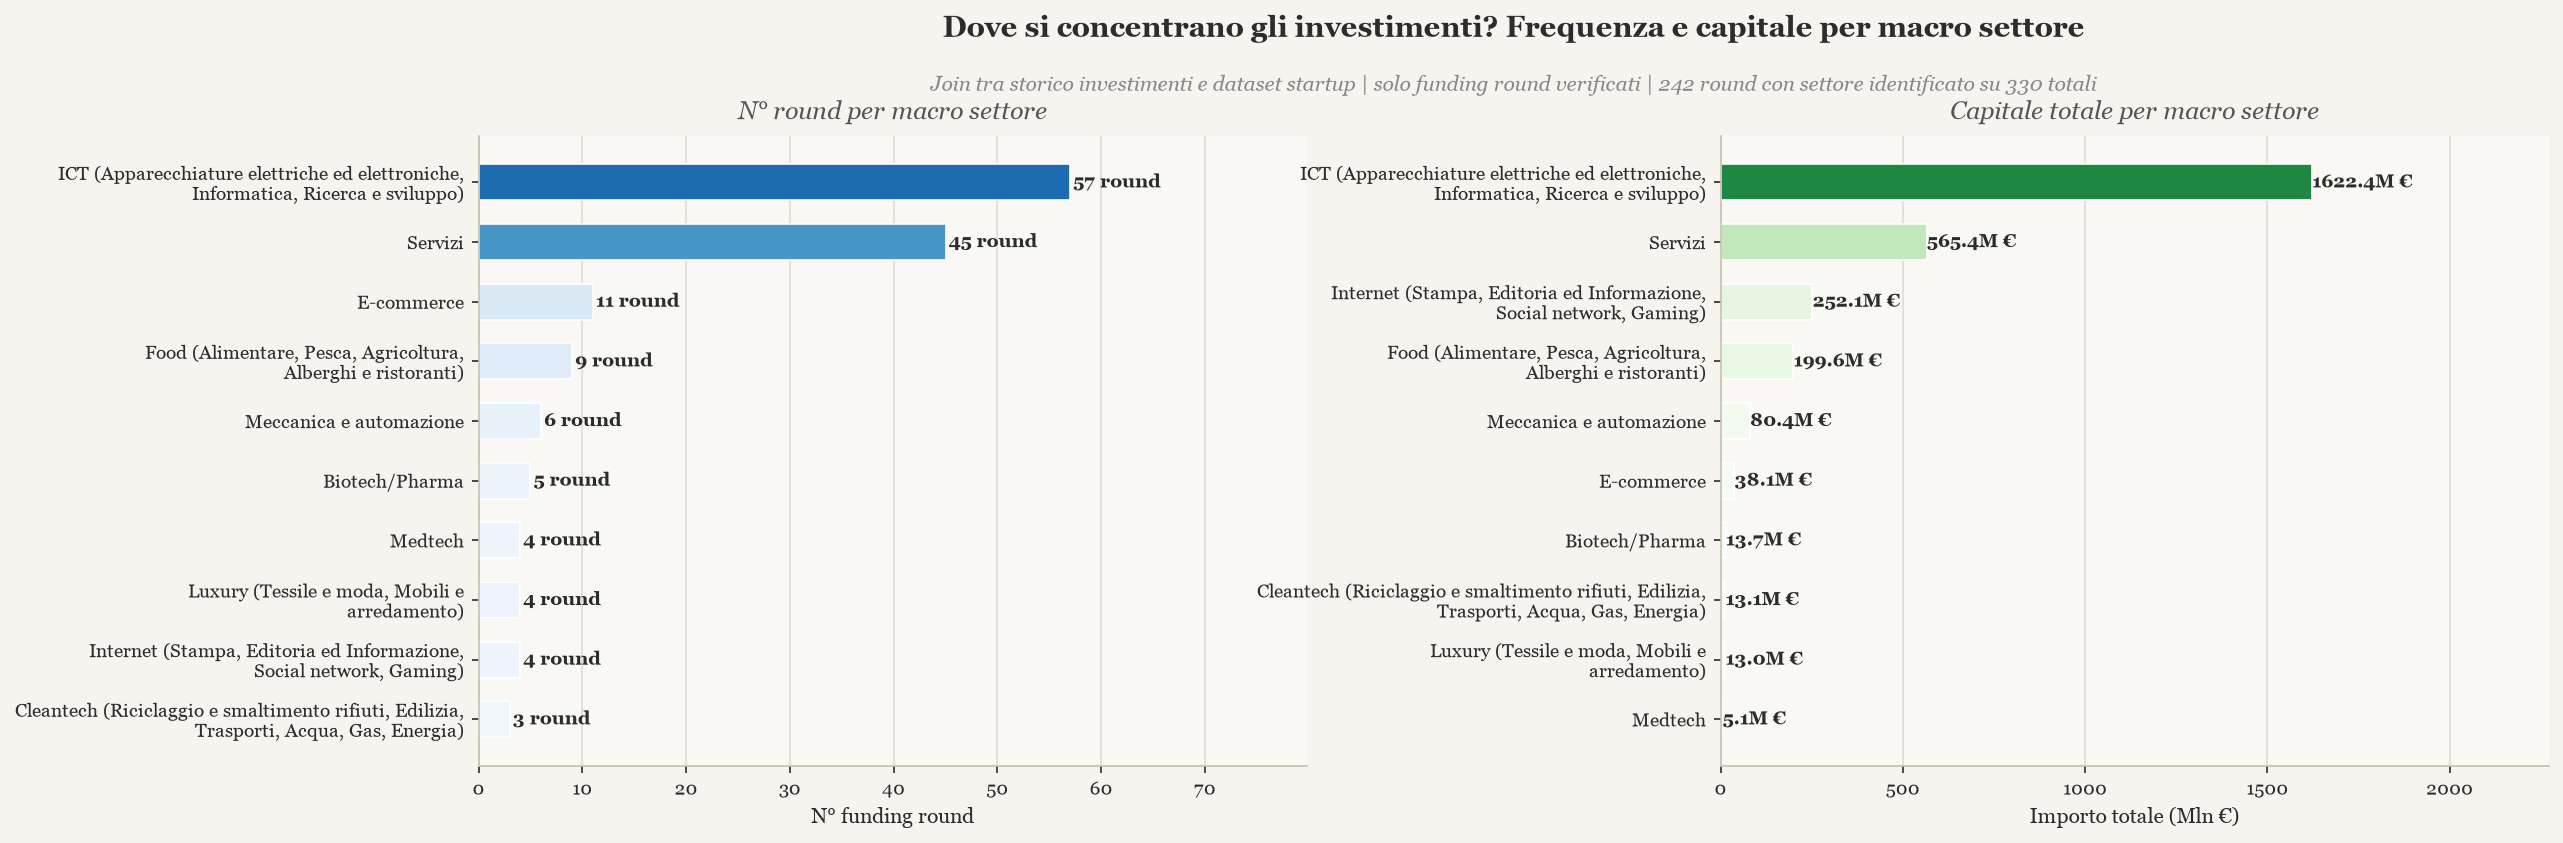

In [24]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np

try:
    fm.findfont('Georgia', rebuild_if_missing=False)
    mpl.rcParams['font.family'] = 'Georgia'
except:
    mpl.rcParams['font.family'] = 'serif'

df_inv  = pd.read_excel("/Users/claudiatimis/Desktop/ANALISI STARTUP/storico_investimenti.xlsx")
df_main = pd.read_excel("/Users/claudiatimis/Desktop/ANALISI STARTUP/OUTPUT_Unione_Aida_Registro .xlsx")

# ── 1. JOIN ───────────────────────────────────────────────────
df_inv['cf']  = df_inv['Codice Fiscale'].astype(str).str.strip()
df_main['cf'] = df_main['codice_fiscale'].astype(str).str.strip()

df = df_inv.merge(
    df_main[['cf', 'macro_settore']],
    on='cf', how='left'
)

# ── 2. FILTRI ─────────────────────────────────────────────────
df['is_verified'] = df['Verifica'].str.startswith('verificato')
df_funding = df[
    (df['is_verified']) &
    (df['Tipo Evento'] == 'funding_round') &
    (df['macro_settore'].notna())
].copy()

df_funding['Importo (Mln €)'] = pd.to_numeric(
    df_funding['Importo (Mln €)'], errors='coerce'
)

# ── 3. AGGREGAZIONE ───────────────────────────────────────────
agg = (
    df_funding.groupby('macro_settore')
    .agg(
        n_round=('Tipo Evento', 'count'),
        capitale=('Importo (Mln €)', 'sum'),
    )
    .reset_index()
)

# Etichette brevi
def wrap_label(text, max_len=30):
    if len(text) <= max_len:
        return text
    mid = len(text) // 2
    split = text.rfind(' ', 0, mid + 15)
    return text[:split] + '\n' + text[split+1:] if split != -1 else text

agg['label'] = agg['macro_settore'].apply(wrap_label)

# ── 4. FIGURA — due pannelli ──────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor('#f7f4ef')
ax1.set_facecolor('#faf8f4')
ax2.set_facecolor('#faf8f4')
fig.subplots_adjust(left=0.04, right=0.96, top=0.82, bottom=0.12, wspace=0.5)

# ── PANNELLO 1: n° round per settore ─────────────────────────
agg1 = agg.sort_values('n_round', ascending=True)

cmap1 = mpl.colormaps['Blues']
norm1 = mpl.colors.Normalize(vmin=0, vmax=agg1['n_round'].max() * 1.3)
colori1 = [cmap1(norm1(n)) for n in agg1['n_round']]

bars1 = ax1.barh(
    agg1['label'], agg1['n_round'],
    color=colori1, edgecolor='white', linewidth=0.8, height=0.6,
)
for bar, (_, row) in zip(bars1, agg1.iterrows()):
    ax1.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{int(row['n_round'])} round",
        va='center', ha='left',
        fontsize=9, color='#2c2c2c', fontweight='bold'
    )

ax1.set_title('N° round per macro settore',
              fontsize=12, color='#555555', pad=8, style='italic')
ax1.set_xlabel('N° funding round', fontsize=10, color='#2c2c2c')
ax1.tick_params(labelsize=9, colors='#2c2c2c')
ax1.set_xlim(0, agg1['n_round'].max() * 1.4)
ax1.xaxis.grid(True, color='#e0dbd4', linewidth=0.8)
ax1.set_axisbelow(True)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_color('#c8bfb0')
ax1.spines['bottom'].set_color('#c8bfb0')

# ── PANNELLO 2: capitale per settore ─────────────────────────
agg2 = agg[agg['capitale'].notna()].sort_values('capitale', ascending=True)

cmap2 = mpl.colormaps['Greens']
norm2 = mpl.colors.Normalize(vmin=0, vmax=agg2['capitale'].max() * 1.3)
colori2 = [cmap2(norm2(n)) for n in agg2['capitale']]

bars2 = ax2.barh(
    agg2['label'], agg2['capitale'],
    color=colori2, edgecolor='white', linewidth=0.8, height=0.6,
)
for bar, (_, row) in zip(bars2, agg2.iterrows()):
    ax2.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{row['capitale']:.1f}M €",
        va='center', ha='left',
        fontsize=9, color='#2c2c2c', fontweight='bold'
    )

ax2.set_title('Capitale totale per macro settore',
              fontsize=12, color='#555555', pad=8, style='italic')
ax2.set_xlabel('Importo totale (Mln €)', fontsize=10, color='#2c2c2c')
ax2.tick_params(labelsize=9, colors='#2c2c2c')
ax2.set_xlim(0, agg2['capitale'].max() * 1.4)
ax2.xaxis.grid(True, color='#e0dbd4', linewidth=0.8)
ax2.set_axisbelow(True)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_color('#c8bfb0')
ax2.spines['bottom'].set_color('#c8bfb0')

# ── 5. TITOLO GENERALE ───────────────────────────────────────
fig.text(
    0.5, 0.93,
    'Dove si concentrano gli investimenti? Frequenza e capitale per macro settore',
    ha='center', fontsize=14, color='#2c2c2c', fontweight='bold'
)
fig.text(
    0.5, 0.87,
    'Join tra storico investimenti e dataset startup | '
    'solo funding round verificati | 242 round con settore identificato su 330 totali',
    ha='center', fontsize=10, color='#888888', style='italic'
)

plt.show()

### Versione 2

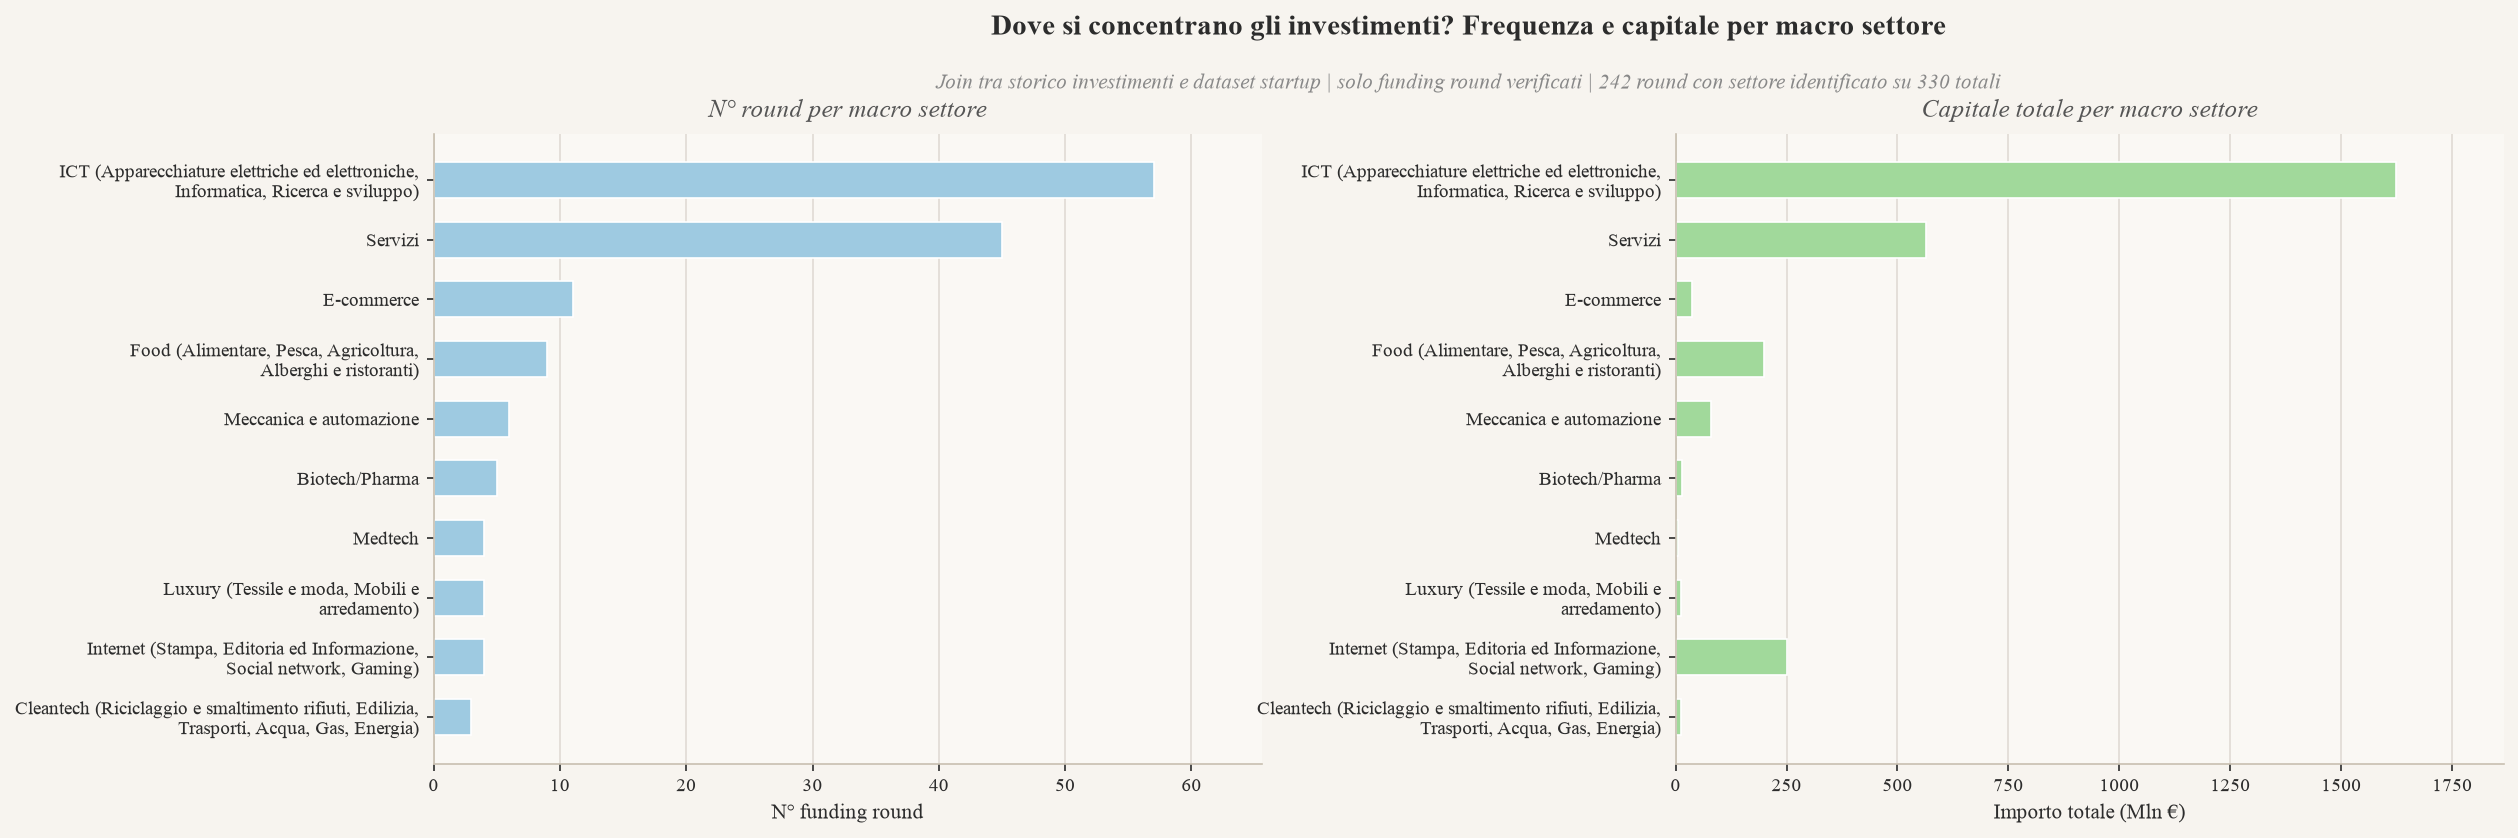

In [25]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd

mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['figure.dpi'] = 150

df_inv  = pd.read_excel("/Users/claudiatimis/Desktop/ANALISI STARTUP/storico_investimenti.xlsx")
df_main = pd.read_excel("/Users/claudiatimis/Desktop/ANALISI STARTUP/OUTPUT_Unione_Aida_Registro .xlsx")

# ── 1. JOIN ───────────────────────────────────────────────────
df_inv['cf']  = df_inv['Codice Fiscale'].astype(str).str.strip()
df_main['cf'] = df_main['codice_fiscale'].astype(str).str.strip()

df = df_inv.merge(
    df_main[['cf', 'macro_settore']],
    on='cf', how='left'
)

# ── 2. FILTRI ─────────────────────────────────────────────────
df['is_verified'] = df['Verifica'].str.startswith('verificato')
df_funding = df[
    (df['is_verified']) &
    (df['Tipo Evento'] == 'funding_round') &
    (df['macro_settore'].notna())
].copy()

df_funding['Importo (Mln €)'] = pd.to_numeric(
    df_funding['Importo (Mln €)'], errors='coerce'
)

# ── 3. AGGREGAZIONE ───────────────────────────────────────────
agg = (
    df_funding.groupby('macro_settore')
    .agg(
        n_round=('Tipo Evento', 'count'),
        capitale=('Importo (Mln €)', 'sum'),
    )
    .reset_index()
    .sort_values('n_round', ascending=True)  # ordine unico per entrambi
    .reset_index(drop=True)
)

def wrap_label(text, max_len=30):
    if len(text) <= max_len:
        return text
    mid = len(text) // 2
    split = text.rfind(' ', 0, mid + 15)
    return text[:split] + '\n' + text[split+1:] if split != -1 else text

agg['label'] = agg['macro_settore'].apply(wrap_label)

# ── 4. FIGURA ────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor('#f7f4ef')
ax1.set_facecolor('#faf8f4')
ax2.set_facecolor('#faf8f4')
fig.subplots_adjust(left=0.04, right=0.96, top=0.82, bottom=0.12, wspace=0.5)

# ── PANNELLO 1: n° round ──────────────────────────────────────
ax1.barh(
    agg['label'], agg['n_round'],
    color='#9ecae1', edgecolor='white', linewidth=0.8, height=0.6,
)

ax1.set_title('N° round per macro settore',
              fontsize=12, color='#555555', pad=8, style='italic')
ax1.set_xlabel('N° funding round', fontsize=10, color='#2c2c2c')
ax1.tick_params(labelsize=9, colors='#2c2c2c')
ax1.set_xlim(0, agg['n_round'].max() * 1.15)
ax1.xaxis.grid(True, color='#e0dbd4', linewidth=0.8)
ax1.set_axisbelow(True)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_color('#c8bfb0')
ax1.spines['bottom'].set_color('#c8bfb0')

# ── PANNELLO 2: capitale — stesso ordine ──────────────────────
ax2.barh(
    agg['label'], agg['capitale'],
    color='#a1d99b', edgecolor='white', linewidth=0.8, height=0.6,
)

ax2.set_title('Capitale totale per macro settore',
              fontsize=12, color='#555555', pad=8, style='italic')
ax2.set_xlabel('Importo totale (Mln €)', fontsize=10, color='#2c2c2c')
ax2.tick_params(labelsize=9, colors='#2c2c2c')
ax2.set_xlim(0, agg['capitale'].max() * 1.15)
ax2.xaxis.grid(True, color='#e0dbd4', linewidth=0.8)
ax2.set_axisbelow(True)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_color('#c8bfb0')
ax2.spines['bottom'].set_color('#c8bfb0')

# ── 5. TITOLO ─────────────────────────────────────────────────
fig.text(
    0.5, 0.93,
    'Dove si concentrano gli investimenti? Frequenza e capitale per macro settore',
    ha='center', fontsize=14, color='#2c2c2c', fontweight='bold'
)
fig.text(
    0.5, 0.87,
    'Join tra storico investimenti e dataset startup | '
    'solo funding round verificati | 242 round con settore identificato su 330 totali',
    ha='center', fontsize=10, color='#888888', style='italic'
)

plt.show()

### STARTUP CHE HANNO FATTO SIA FUNDING CHE SHARE SALE

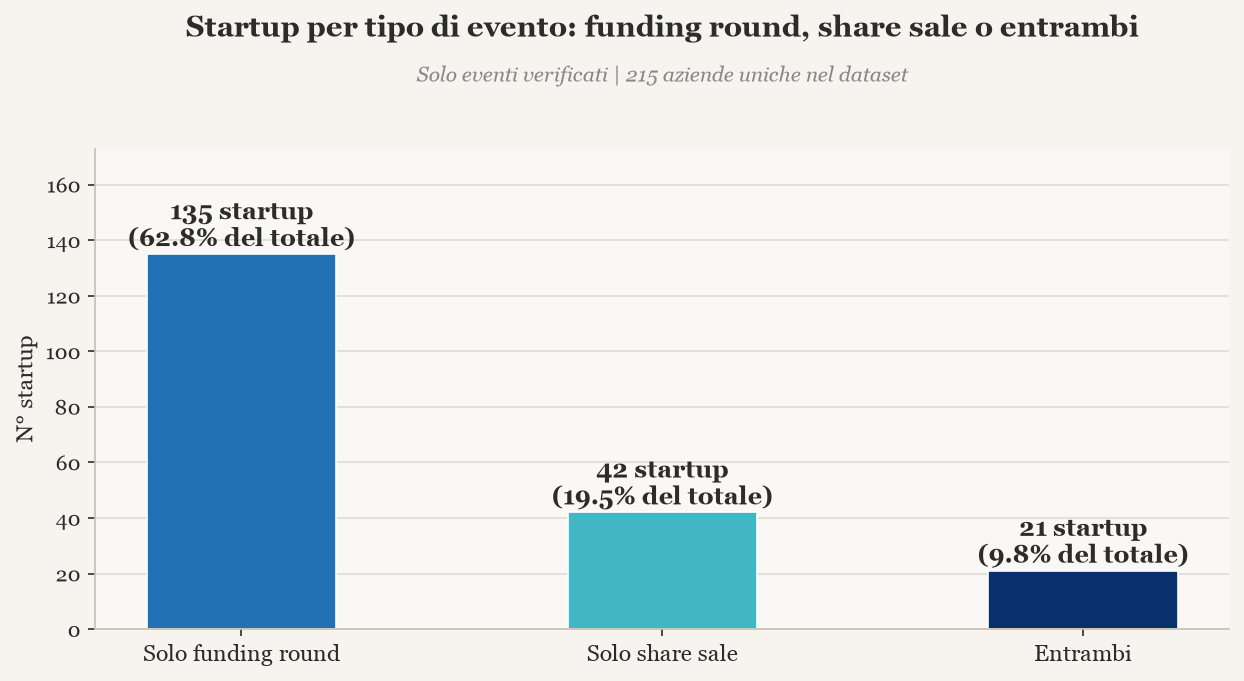

In [26]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm
import pandas as pd

try:
    fm.findfont('Georgia', rebuild_if_missing=False)
    mpl.rcParams['font.family'] = 'Georgia'
except:
    mpl.rcParams['font.family'] = 'serif'

df = pd.read_excel("/Users/claudiatimis/Desktop/ANALISI STARTUP/storico_investimenti.xlsx")

# ── 1. PULIZIA ───────────────────────────────────────────────
df['is_verified'] = df['Verifica'].str.startswith('verificato')
df_ver = df[df['is_verified']].copy()

funding   = set(df_ver[df_ver['Tipo Evento'] == 'funding_round']['Azienda'])
share     = set(df_ver[df_ver['Tipo Evento'] == 'share_sale']['Azienda'])
entrambi  = funding & share
solo_fund = funding - share
solo_share= share - funding

n_tot = df_ver['Azienda'].nunique()

# ── 2. DATI ───────────────────────────────────────────────────
categorie = [
    f'Solo funding round',
    f'Solo share sale',
    f'Entrambi',
]
valori = [len(solo_fund), len(solo_share), len(entrambi)]
pct    = [round(v / n_tot * 100, 1) for v in valori]
colori = ['#2171b5', '#41b6c4', '#08306b']

# ── 3. FIGURA ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('#f7f4ef')
ax.set_facecolor('#faf8f4')
fig.subplots_adjust(left=0.08, right=0.92, top=0.78, bottom=0.14)

bars = ax.bar(
    categorie, valori,
    color=colori,
    edgecolor='white',
    linewidth=0.8,
    width=0.45,
)

for bar, v, p in zip(bars, valori, pct):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{v} startup\n({p}% del totale)",
        ha='center', va='bottom',
        fontsize=12, color='#2c2c2c', fontweight='bold'
    )

# ── 4. STILE ─────────────────────────────────────────────────
fig.text(
    0.5, 0.93,
    'Startup per tipo di evento: funding round, share sale o entrambi',
    ha='center', fontsize=14, color='#2c2c2c', fontweight='bold'
)
fig.text(
    0.5, 0.87,
    f'Solo eventi verificati | {n_tot} aziende uniche nel dataset',
    ha='center', fontsize=10, color='#888888', style='italic'
)

ax.set_ylabel('N° startup', fontsize=11, color='#2c2c2c')
ax.set_xlabel('')
ax.tick_params(axis='x', labelsize=11, colors='#2c2c2c')
ax.tick_params(axis='y', labelsize=10, colors='#2c2c2c')
ax.set_ylim(0, max(valori) * 1.28)
ax.yaxis.grid(True, color='#e0dbd4', linewidth=0.8)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#c8bfb0')
ax.spines['bottom'].set_color('#c8bfb0')

plt.show()

### Versione 2

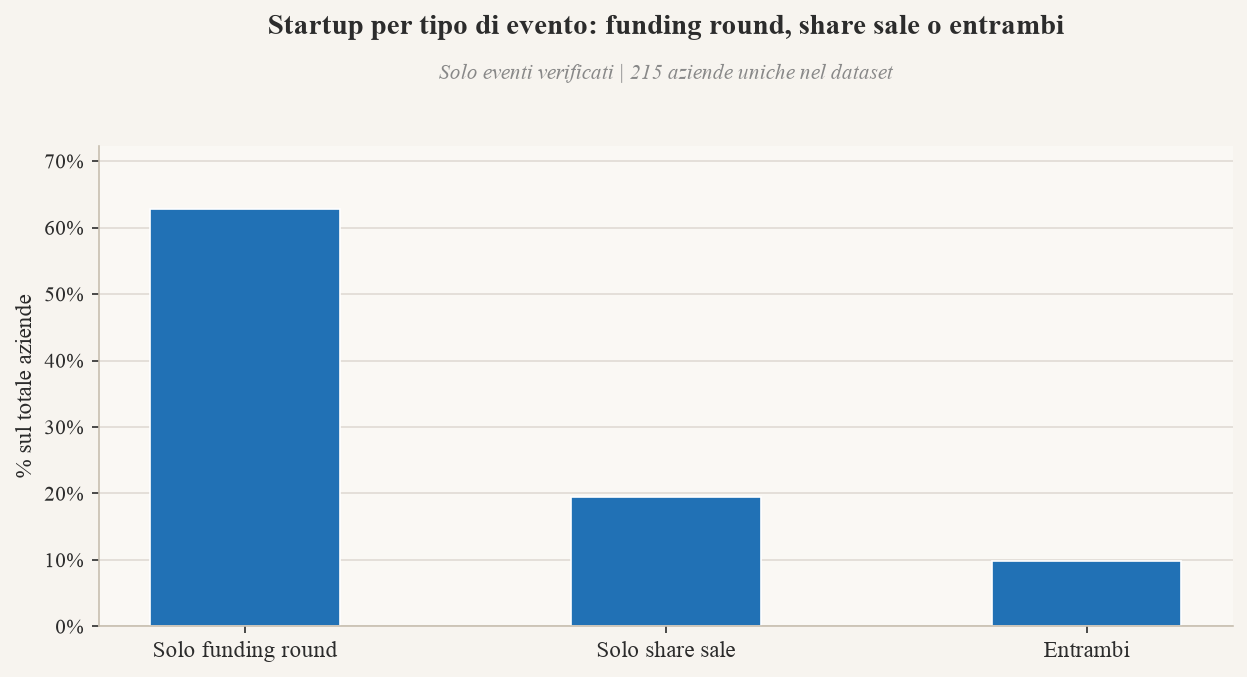

In [27]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd

mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['figure.dpi'] = 150

df = pd.read_excel("/Users/claudiatimis/Desktop/ANALISI STARTUP/storico_investimenti.xlsx")

# ── 1. PULIZIA ───────────────────────────────────────────────
df['is_verified'] = df['Verifica'].str.startswith('verificato')
df_ver = df[df['is_verified']].copy()

funding   = set(df_ver[df_ver['Tipo Evento'] == 'funding_round']['Azienda'])
share     = set(df_ver[df_ver['Tipo Evento'] == 'share_sale']['Azienda'])
entrambi  = funding & share
solo_fund = funding - share
solo_share= share - funding

n_tot = df_ver['Azienda'].nunique()

# ── 2. DATI ───────────────────────────────────────────────────
categorie = ['Solo funding round', 'Solo share sale', 'Entrambi']
valori    = [len(solo_fund), len(solo_share), len(entrambi)]
pct       = [round(v / n_tot * 100, 1) for v in valori]

pct, categorie = zip(*sorted(zip(pct, categorie), reverse=True))

# ── 3. FIGURA ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('#f7f4ef')
ax.set_facecolor('#faf8f4')
fig.subplots_adjust(left=0.08, right=0.92, top=0.78, bottom=0.14)

ax.bar(
    categorie, pct,
    color='#2171b5',
    edgecolor='white',
    linewidth=0.8,
    width=0.45,
)

# ── 4. STILE ─────────────────────────────────────────────────
fig.text(
    0.5, 0.93,
    'Startup per tipo di evento: funding round, share sale o entrambi',
    ha='center', fontsize=14, color='#2c2c2c', fontweight='bold'
)
fig.text(
    0.5, 0.87,
    f'Solo eventi verificati | {n_tot} aziende uniche nel dataset',
    ha='center', fontsize=10, color='#888888', style='italic'
)

ax.set_ylabel('% sul totale aziende', fontsize=11, color='#2c2c2c')
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.tick_params(axis='x', labelsize=11, colors='#2c2c2c')
ax.tick_params(axis='y', labelsize=10, colors='#2c2c2c')
ax.set_ylim(0, max(pct) * 1.15)
ax.yaxis.grid(True, color='#e0dbd4', linewidth=0.8)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#c8bfb0')
ax.spines['bottom'].set_color('#c8bfb0')

plt.show()

In [28]:
funding   = set(df_ver[df_ver['Tipo Evento'] == 'funding_round']['Azienda'])
share     = set(df_ver[df_ver['Tipo Evento'] == 'share_sale']['Azienda'])
entrambi  = funding & share
solo_fund = funding - share
solo_share= share - funding

print("=== SOLO FUNDING ROUND ===")
for n in sorted(solo_fund):
    print(f"  • {n}")

print(f"\n=== SOLO SHARE SALE ===")
for n in sorted(solo_share):
    print(f"  • {n}")

print(f"\n=== ENTRAMBI (funding + share sale) ===")
for n in sorted(entrambi):
    print(f"  • {n}")

=== SOLO FUNDING ROUND ===
  • 2INNOVATION S.R.L.
  • ALGOJOB S.R.L.
  • Aion Tech IN Liquidazione
  • Algojob
  • Algor LAB
  • Alkenium
  • Alpha Mobility IN Liquidazione
  • Alter ECO Pulp
  • Aspire
  • Audion Italy
  • Axxelera
  • BCC STUDIO S.R.L.
  • BLU Martin Yachts
  • C Next
  • CARGOFUL S.R.L.
  • Carletti
  • Cassandra
  • Christian Dominici
  • Collecto
  • Covision Media
  • DBRIDGE S.R.L.
  • DIDIMORA SRL
  • DKY
  • Daimon
  • Data Masters
  • Datapizza
  • Delivery Care Care
  • Delivery Valley
  • Designtech
  • Digital Fashion Ovvero Digital Fashion
  • Donux
  • Dreamfarm
  • Drinkme
  • ENPHOS S.R.L.
  • ESG
  • EWIBE S.R.L.
  • EXA Applications
  • EXO LAB Italia
  • Ebamed
  • Ecommerce Company
  • Engen Company
  • Eoliann
  • Equixly
  • Ewibe
  • FLYTED S.R.L.
  • FOOLFARM S.P.A.
  • FUTURA S.P.A.
  • Feral
  • Flash Innovations
  • Fler
  • Flyted
  • Foolfarm
  • From
  • G D G Engineering
  • Green Future Project IN Forma Abbrevia TA Anche Green Future Pr

### CONFRONTO STADIO STARTUP X ROUND RICEVUTI

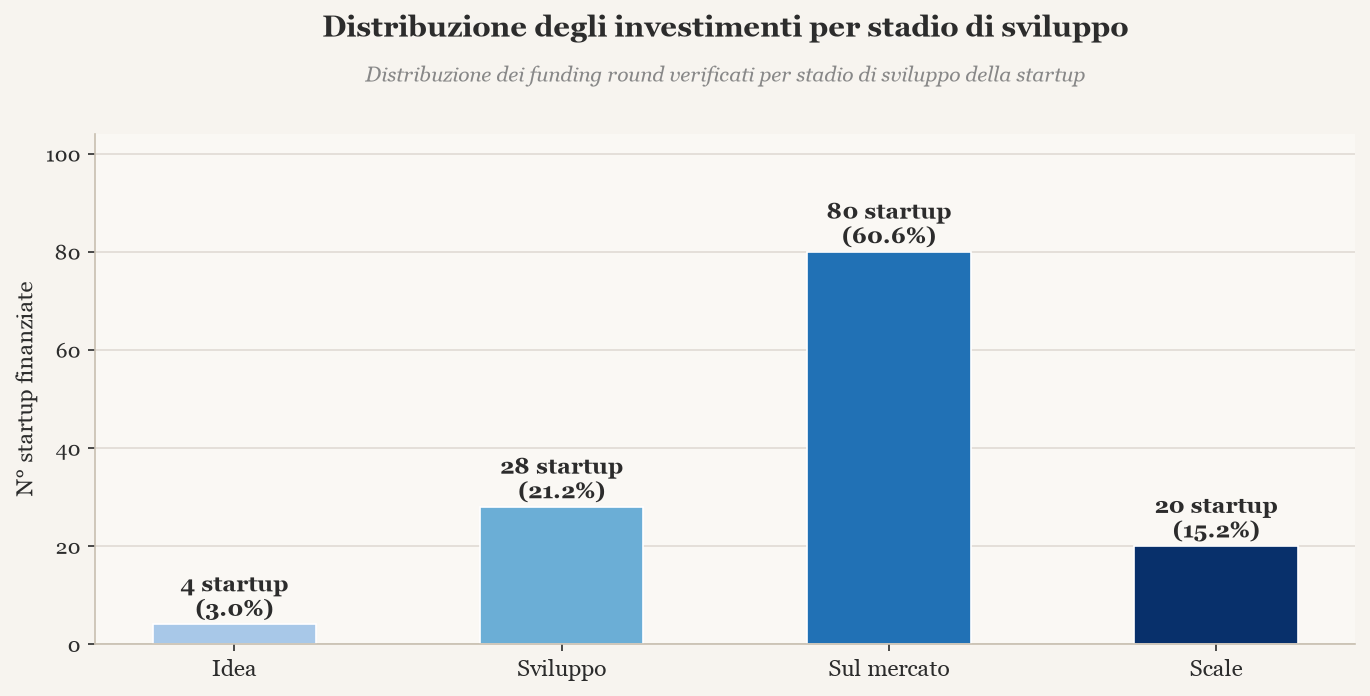

In [29]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm
import pandas as pd

try:
    fm.findfont('Georgia', rebuild_if_missing=False)
    mpl.rcParams['font.family'] = 'Georgia'
except:
    mpl.rcParams['font.family'] = 'serif'

df_inv  = pd.read_excel("/Users/claudiatimis/Desktop/ANALISI STARTUP/storico_investimenti.xlsx")
df_main = pd.read_excel("/Users/claudiatimis/Desktop/ANALISI STARTUP/OUTPUT_Unione_Aida_Registro .xlsx")

# ── 1. JOIN ───────────────────────────────────────────────────
df_inv['cf']  = df_inv['Codice Fiscale'].astype(str).str.strip()
df_main['cf'] = df_main['codice_fiscale'].astype(str).str.strip()

df = df_inv.merge(
    df_main[['cf', 'stadio_startup']],
    on='cf', how='left'
)

# ── 2. FILTRI ────────────────────────────────────────────────
df['is_verified'] = df['Verifica'].str.startswith('verificato')
df_funding = df[
    (df['is_verified']) &
    (df['Tipo Evento'] == 'funding_round') &
    (df['stadio_startup'].notna())
].copy()

round_per_az = (
    df_funding.groupby(['Azienda', 'stadio_startup'])
    .size()
    .reset_index(name='n_round')
)

ordine_stadio = ['Idea', 'Sviluppo', 'Sul mercato', 'Scale']
colori_stadio = ['#a8c8e8', '#6baed6', '#2171b5', '#08306b']

agg = (
    round_per_az.groupby('stadio_startup')['n_round']
    .agg(n_startup='count')
    .reset_index()
)
agg['stadio_startup'] = pd.Categorical(
    agg['stadio_startup'], categories=ordine_stadio, ordered=True
)
agg = agg.sort_values('stadio_startup').reset_index(drop=True)
agg['colore'] = colori_stadio[:len(agg)]
agg['pct'] = (agg['n_startup'] / agg['n_startup'].sum() * 100).round(1)

# ── 3. FIGURA ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#f7f4ef')
ax.set_facecolor('#faf8f4')
fig.subplots_adjust(left=0.08, right=0.92, top=0.80, bottom=0.12)

bars = ax.bar(
    agg['stadio_startup'].astype(str),
    agg['n_startup'],
    color=agg['colore'],
    edgecolor='white',
    linewidth=0.8,
    width=0.5,
)

for bar, (_, row) in zip(bars, agg.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{int(row['n_startup'])} startup\n({row['pct']}%)",
        ha='center', va='bottom',
        fontsize=11, color='#2c2c2c', fontweight='bold'
    )

# ── 4. STILE ─────────────────────────────────────────────────
fig.text(
    0.5, 0.93,
    'Distribuzione degli investimenti per stadio di sviluppo',
    ha='center', fontsize=14, color='#2c2c2c', fontweight='bold'
)
fig.text(
    0.5, 0.87,
    'Distribuzione dei funding round verificati per stadio di sviluppo della startup',
    ha='center', fontsize=10, color='#888888', style='italic'
)

ax.set_ylabel('N° startup finanziate', fontsize=11, color='#2c2c2c')
ax.set_xlabel('')
ax.tick_params(axis='x', labelsize=11, colors='#2c2c2c')
ax.tick_params(axis='y', labelsize=10, colors='#2c2c2c')
ax.set_ylim(0, agg['n_startup'].max() * 1.3)
ax.yaxis.grid(True, color='#e0dbd4', linewidth=0.8)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#c8bfb0')
ax.spines['bottom'].set_color('#c8bfb0')

plt.show()

### Versione 2

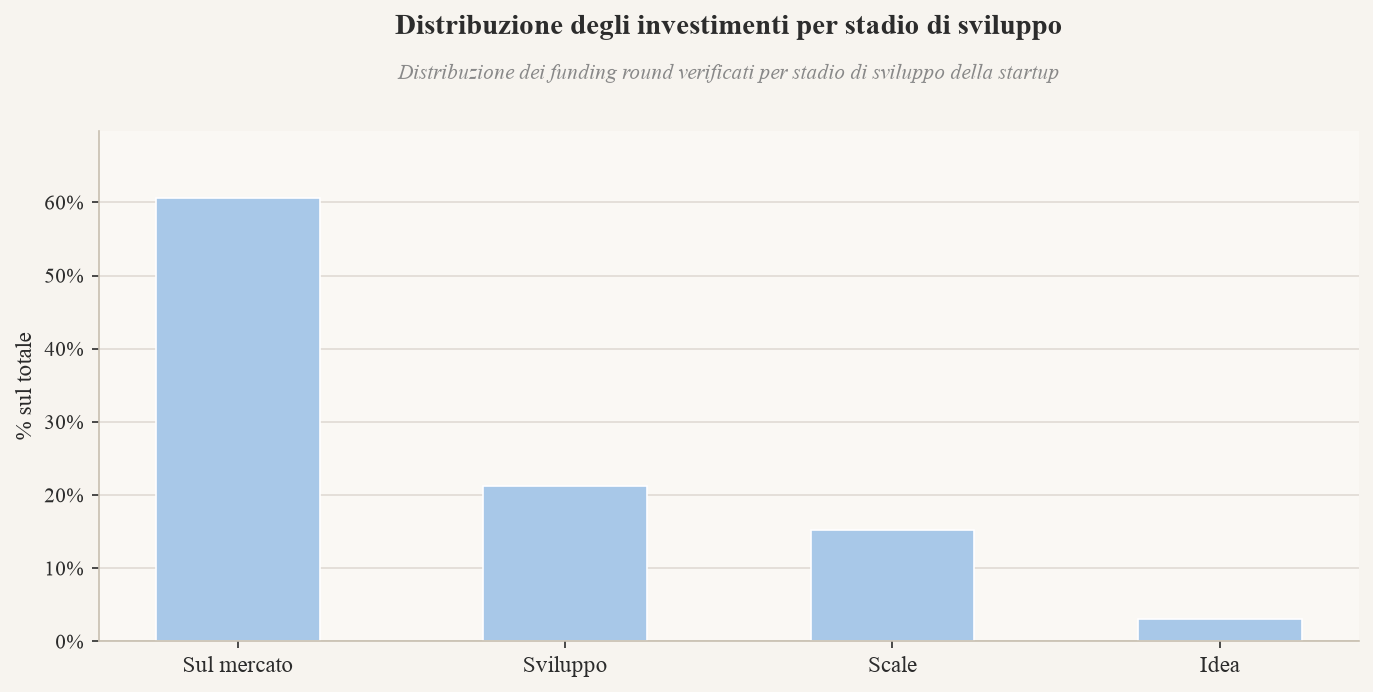

In [30]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd

mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['figure.dpi'] = 150

df_inv  = pd.read_excel("/Users/claudiatimis/Desktop/ANALISI STARTUP/storico_investimenti.xlsx")
df_main = pd.read_excel("/Users/claudiatimis/Desktop/ANALISI STARTUP/OUTPUT_Unione_Aida_Registro .xlsx")

# ── 1. JOIN ───────────────────────────────────────────────────
df_inv['cf']  = df_inv['Codice Fiscale'].astype(str).str.strip()
df_main['cf'] = df_main['codice_fiscale'].astype(str).str.strip()

df = df_inv.merge(
    df_main[['cf', 'stadio_startup']],
    on='cf', how='left'
)

# ── 2. FILTRI ────────────────────────────────────────────────
df['is_verified'] = df['Verifica'].str.startswith('verificato')
df_funding = df[
    (df['is_verified']) &
    (df['Tipo Evento'] == 'funding_round') &
    (df['stadio_startup'].notna())
].copy()

round_per_az = (
    df_funding.groupby(['Azienda', 'stadio_startup'])
    .size()
    .reset_index(name='n_round')
)

agg = (
    round_per_az.groupby('stadio_startup')['n_round']
    .agg(n_startup='count')
    .reset_index()
    .sort_values('n_startup', ascending=False)
    .reset_index(drop=True)
)
agg['pct'] = (agg['n_startup'] / agg['n_startup'].sum() * 100).round(1)

# ── 3. FIGURA ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#f7f4ef')
ax.set_facecolor('#faf8f4')
fig.subplots_adjust(left=0.08, right=0.92, top=0.80, bottom=0.12)

ax.bar(
    agg['stadio_startup'].astype(str),
    agg['pct'],
    color='#a8c8e8',
    edgecolor='white',
    linewidth=0.8,
    width=0.5,
)

# ── 4. STILE ─────────────────────────────────────────────────
fig.text(
    0.5, 0.93,
    'Distribuzione degli investimenti per stadio di sviluppo',
    ha='center', fontsize=14, color='#2c2c2c', fontweight='bold'
)
fig.text(
    0.5, 0.87,
    'Distribuzione dei funding round verificati per stadio di sviluppo della startup',
    ha='center', fontsize=10, color='#888888', style='italic'
)

ax.set_ylabel('% sul totale', fontsize=11, color='#2c2c2c')
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.tick_params(axis='x', labelsize=11, colors='#2c2c2c')
ax.tick_params(axis='y', labelsize=10, colors='#2c2c2c')
ax.set_ylim(0, agg['pct'].max() * 1.15)
ax.yaxis.grid(True, color='#e0dbd4', linewidth=0.8)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#c8bfb0')
ax.spines['bottom'].set_color('#c8bfb0')

plt.show()